# Paper 2 — Goal 3 Stage E
# Full controlled perturbation experiment + frozen Goal-2 clinical inference — v1.1.0

This notebook is the **first clinically unblinded controlled-perturbation notebook for Goal 3**.

It may be run only after all four upstream gates have passed:

1. Goal 3 Stage A natural Q–A localization and deterministic source freeze;
2. Goal 3 Stage B signal-only low/medium/high dose seal;
3. Goal 3 Stage C Q+A measurement preflight;
4. Goal 3 Stage D Goal-2 model-bundle bridge with exact repeat-1 OOF reproduction.

The Stage-D bridge has already established that the five serialized fold bundles reproduce the authoritative Goal-2 predictions to machine precision. This notebook **never refits, tunes, recalibrates, or residualizes on perturbed audio**.

## Primary controlled estimand

For each prespecified held-out source recording:

- run an unmodified **freshly re-segmented baseline**;
- apply the frozen low / medium / high digital acquisition perturbations;
- rerun preprocessing, segmentation, Q extraction, and A extraction;
- retain all exemplar-level outcomes and all support/extraction failures;
- average stochastic/exemplar outputs within participant × transform × dose for primary inference;
- apply only the participant's sealed fold-specific `M_A`, `M_A+Q`, and `M_A-resQ` models;
- compute paired changes in Q, A, model output, and prediction error relative to the same freshly measured baseline.

The Goal-2 model-bundle reproduction gate used the original frozen Goal-2 representation. That is a **model provenance check**. The primary Goal-3 intervention estimand instead compares perturbed measurements against a **fresh Goal-3 baseline measured through the same end-to-end path**, exactly as prespecified.

## Frozen perturbation structures

The final Stage-B seal contains six retained structures:

- QADD — stationary colored broadband interference, **5 realizations/dose**;
- QGAIN — uniform level shift, 1 realization/dose;
- QGAIN — smooth time-varying gain, 1 realization/dose;
- QREV — RMS-matched RIR convolution, **3 RIR exemplars/dose**;
- QCHAN — upper-band restriction, **3 filter exemplars/dose**;
- QDIST — symmetric hard clipping, 1 realization/dose.

The outcome-blind AM-QADD structure that failed calibration is not reintroduced.

## Interpretation boundary

A reproducible same-source dose response supports **direct sensitivity to the imposed digital transformation**. It does not establish that the same transformation caused an observational natural-data association, and it does not generalize one transformation into a generic device/room/artifact claim.

**v1.0.1 patch:** Notebook 33 is imported in an isolated namespace so its internal constants cannot overwrite Stage-E configuration. No scientific, perturbation, measurement, model, or inferential logic changed.

**v1.0.2 patch:** adds a hard pre-execution runtime dependency gate for the exact pinned Silero/ONNX/reverberation runtime. No scientific analysis logic changed.

**v1.1.0 reliability revision:** self-bootstraps the exact pinned Python measurement runtime when missing, preserves Stage-E globals in an isolated Notebook-33 namespace, performs a live end-to-end smoke test before the cohort run, and retains source-level decode/segmentation failures instead of aborting the full experiment. Scientific estimands, sealed doses, feature definitions, model states, and inferential rules are unchanged.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import re
import shutil
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display, Markdown
from statsmodels.stats.multitest import multipletests

ENGINE_VERSION = "goal3-controlled-perturbation-primary-v1.0.0"
BASE_SEED = 20260825
N_BOOTSTRAPS = 2000
MODELS = ["M_A", "M_A+Q", "M_A-resQ"]
TASKS = ["diagnosis", "severity"]

STAGEE_EXPECTED = {
    "diagnosis_sources": 199,
    "severity_sources": 145,
    "outer_folds": 5,
    "sealed_dose_rows": 18,
    "sealed_transforms": 6,
    "execution_rows_per_source": 43,  # baseline + 42 nonzero exemplar rows
}

# This NumPy 2.5/joblib warning is a serialization implementation warning only.
# Stage D already verified round-trip predictions exactly.
warnings.filterwarnings(
    "ignore",
    message=r"Setting the shape on a NumPy array has been deprecated.*",
    category=DeprecationWarning,
    module=r"joblib\.numpy_pickle",
)

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def stable_hash(*parts):
    payload = "|".join(str(p) for p in parts)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

def json_safe(value):
    if value is pd.NA:
        return None
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return None if pd.isna(value) else value.isoformat()
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return [json_safe(v) for v in value]
    return value

def atomic_json(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(f".{path.name}.tmp")
    tmp.write_text(
        json.dumps(json_safe(payload), indent=2, sort_keys=True),
        encoding="utf-8",
    )
    os.replace(tmp, path)

def atomic_csv(frame, path, *, allow_empty=False):
    path = Path(path)
    if frame.empty and not allow_empty:
        raise ValueError(f"Refusing to write empty CSV: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(f".{path.name}.tmp")
    frame.to_csv(tmp, index=False)
    if tmp.stat().st_size == 0:
        raise IOError(f"Temporary CSV is empty: {tmp}")
    os.replace(tmp, path)

def read_csv_checked(path, required=None):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(path)
    frame = pd.read_csv(path, low_memory=False)
    if required:
        missing = set(required) - set(frame.columns)
        if missing:
            raise KeyError(f"{path.name}: missing columns {sorted(missing)}")
    return frame

def find_project_root():
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        candidate = Path(override).expanduser().resolve()
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (candidate / "outputs" / "goal3").exists()
        ):
            return candidate
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {candidate}")

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (candidate / "outputs" / "goal3").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate Paper_2_Leakage/Code project root. "
        "Run this notebook from inside the Paper 2 code repository."
    )

ROOT = find_project_root()
print("Project root:", ROOT)
print("Engine:", ENGINE_VERSION)
print("Python:", sys.version.split()[0])


Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: goal3-controlled-perturbation-primary-v1.0.0
Python: 3.14.2


## 0A. Exact runtime dependency gate

The controlled experiment uses the pinned Paper-1 segmentation and measurement runtime. It must therefore fail **before any source execution** if the current Jupyter kernel does not contain the required runtime.

The exact pinned Paper-1 commit used by Goal 3 specifies:

- `silero-vad==6.2.1`;
- `onnxruntime>=1.18,<2`;
- Python `>=3.11,<3.13`.

The Paper-1 reverberation extra pins `gammatone==1.0.3`, and the earlier Goal-3 signal-only calibration explicitly required `gammatone`, `ffmpeg`, and `ffprobe`.

This cell is an audit only; it never installs or upgrades packages automatically.

In [2]:
import importlib
import importlib.metadata as importlib_metadata
import importlib.util
import shutil
import subprocess
from packaging.version import Version

# Self-bootstrap ONLY the exact governed Python runtime dependencies needed
# by the pinned Paper-1 measurement implementation.  No analysis package,
# dose, model, or scientific configuration is modified here.
AUTO_INSTALL_PINNED_RUNTIME = True

PINNED_PYTHON_REQUIREMENTS = [
    "silero-vad==6.2.1",
    "onnxruntime>=1.18,<2",
    "gammatone==1.0.3",
]

def _dist_version(dist_name):
    try:
        return importlib_metadata.version(dist_name)
    except Exception:
        return ""

def _importable(import_name):
    try:
        return importlib.util.find_spec(import_name) is not None
    except Exception:
        return False

def _runtime_state():
    return {
        "silero_vad_importable": _importable("silero_vad"),
        "silero_vad_version": _dist_version("silero-vad"),
        "onnxruntime_importable": _importable("onnxruntime"),
        "onnxruntime_version": _dist_version("onnxruntime"),
        "gammatone_importable": _importable("gammatone"),
        "gammatone_version": _dist_version("gammatone"),
        "torch_importable": _importable("torch"),
        "torch_version": _dist_version("torch"),
        "ffmpeg": shutil.which("ffmpeg"),
        "ffprobe": shutil.which("ffprobe"),
    }

def _python_requirements_ok(state):
    problems = []

    if not state["silero_vad_importable"]:
        problems.append("silero-vad is not importable")
    elif state["silero_vad_version"] != "6.2.1":
        problems.append(
            f"silero-vad={state['silero_vad_version']!r}; expected 6.2.1"
        )

    if not state["onnxruntime_importable"]:
        problems.append("onnxruntime is not importable")
    else:
        try:
            version = Version(str(state["onnxruntime_version"]))
            if not (Version("1.18") <= version < Version("2")):
                problems.append(
                    f"onnxruntime={state['onnxruntime_version']!r}; required >=1.18,<2"
                )
        except Exception:
            problems.append(
                f"could not parse onnxruntime version {state['onnxruntime_version']!r}"
            )

    if not state["gammatone_importable"]:
        problems.append("gammatone is not importable")
    elif state["gammatone_version"] != "1.0.3":
        problems.append(
            f"gammatone={state['gammatone_version']!r}; expected 1.0.3"
        )

    # silero-vad depends on torch; verify importability explicitly.
    if not state["torch_importable"]:
        problems.append("torch is not importable")

    return problems

runtime_before = _runtime_state()
python_problems = _python_requirements_ok(runtime_before)

if python_problems and AUTO_INSTALL_PINNED_RUNTIME:
    print("=" * 76)
    print("PINNED PAPER-1 PYTHON RUNTIME: BOOTSTRAP REQUIRED")
    print("=" * 76)
    print("Current kernel:", sys.executable)
    print("Problems detected:")
    for problem in python_problems:
        print(" -", problem)

    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",
        *PINNED_PYTHON_REQUIREMENTS,
    ]

    print("\nInstalling exact governed dependencies into THIS kernel environment:")
    print(" ".join(command))
    subprocess.check_call(command)

    importlib.invalidate_caches()

runtime_after = _runtime_state()
python_problems = _python_requirements_ok(runtime_after)

# ffmpeg/ffprobe are system executables and are not silently substituted.
system_problems = []
if not runtime_after["ffmpeg"]:
    system_problems.append("ffmpeg is not available on PATH")
if not runtime_after["ffprobe"]:
    system_problems.append("ffprobe is not available on PATH")

if python_problems or system_problems:
    print("\nCURRENT JUPYTER KERNEL:")
    print(sys.executable)
    print("\nRUNTIME DEPENDENCY GATE: FAIL")
    for problem in python_problems + system_problems:
        print(" -", problem)

    if python_problems:
        print(
            "\nThe pinned Python packages could not be made available in the "
            "current live kernel. Restart this kernel once, then rerun this "
            "same notebook from the top."
        )

    raise RuntimeError(
        "Pinned Paper-1 runtime dependency gate failed. "
        "No controlled source execution is allowed."
    )

# Import AFTER any conditional installation.
import silero_vad
import onnxruntime
import gammatone
import torch
from silero_vad import load_silero_vad

# Functional ONNX smoke test before any controlled source execution.
_silero_smoke_model = load_silero_vad(onnx=True)
del _silero_smoke_model

RUNTIME_AUDIT = {
    "python_executable": sys.executable,
    "python_version": sys.version.split()[0],
    "silero_vad": _dist_version("silero-vad"),
    "onnxruntime": _dist_version("onnxruntime"),
    "gammatone": _dist_version("gammatone"),
    "torch": _dist_version("torch"),
    "ffmpeg": runtime_after["ffmpeg"],
    "ffprobe": runtime_after["ffprobe"],
    "auto_install_enabled": AUTO_INSTALL_PINNED_RUNTIME,
}

print("=" * 76)
print("PINNED PAPER-1 RUNTIME DEPENDENCY GATE: PASS")
print("=" * 76)
for key, value in RUNTIME_AUDIT.items():
    print(f"{key}: {value}")
print("Silero VAD 6.2.1 ONNX model load: PASS")


PINNED PAPER-1 RUNTIME DEPENDENCY GATE: PASS
python_executable: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\.venv\Scripts\python.exe
python_version: 3.14.2
silero_vad: 6.2.1
onnxruntime: 1.29.0
gammatone: 1.0.3
torch: 2.13.0
ffmpeg: C:\ffmpeg\bin\ffmpeg.EXE
ffprobe: C:\ffmpeg\bin\ffprobe.EXE
auto_install_enabled: True
Silero VAD 6.2.1 ONNX model load: PASS


## 1. Import the exact already-passed Goal-3 Q+A measurement implementation

Rather than maintaining a second copy of the long signal-processing/acoustic extractor, this notebook imports the **exact executable implementation from the passed Notebook 33** up to—but not including—its two-source preflight experiment.

This is deliberate provenance control:

- the imported notebook is hashed into this Stage-E run signature;
- the exact pinned Paper-1 implementation, segmentation logic, Q extractor, A extractor, and validated transformation helpers are reused;
- Stage E does not silently reimplement those measurement definitions.

The local repository therefore must retain:

`33_goal3_stage_c_qa_measurement_preflight_final_v1_0_2.ipynb`

In [3]:
PREFLIGHT_NOTEBOOK_NAME = "33_goal3_stage_c_qa_measurement_preflight_final_v1_0_2.ipynb"

def locate_local_file(name):
    direct = [
        Path.cwd() / name,
        ROOT / name,
        ROOT / "notebooks" / name,
        ROOT / "Code" / name,
    ]
    for path in direct:
        if path.exists():
            return path.resolve()

    matches = list(ROOT.rglob(name))
    if len(matches) == 1:
        return matches[0].resolve()
    if len(matches) > 1:
        return sorted(matches, key=lambda p: (len(p.parts), str(p)))[0].resolve()

    raise FileNotFoundError(
        f"Required passed preflight notebook not found under project root: {name}"
    )

PREFLIGHT_NOTEBOOK = locate_local_file(PREFLIGHT_NOTEBOOK_NAME)
PREFLIGHT_IMPLEMENTATION_SHA256 = sha256_file(PREFLIGHT_NOTEBOOK)
preflight_nb = json.loads(PREFLIGHT_NOTEBOOK.read_text(encoding="utf-8"))

# Execute Notebook 33 in its own namespace.  Its own constants/output paths
# must never overwrite Stage-E configuration.
preflight_ns = {
    "__name__": "__goal3_stageC_preflight_import__",
    "__file__": str(PREFLIGHT_NOTEBOOK),
}

stop_found = False
executed_code_cells = 0

for cell_index, cell in enumerate(preflight_nb.get("cells", [])):
    source = "".join(cell.get("source", []))

    if (
        cell.get("cell_type") == "markdown"
        and "## 7. Two-path baseline verification" in source
    ):
        stop_found = True
        break

    if cell.get("cell_type") == "code" and source.strip():
        exec(
            compile(
                source,
                f"{PREFLIGHT_NOTEBOOK.name}::<cell {cell_index}>",
                "exec",
            ),
            preflight_ns,
            preflight_ns,
        )
        executed_code_cells += 1

if not stop_found:
    raise RuntimeError(
        "Could not find the controlled preflight section boundary in Notebook 33."
    )

required_measurement_symbols = [
    "decode_source",
    "transform_candidate",
    "extract_all_q",
    "native_to_analysis_16k",
    "extract_a_from_analysis_views",
    "load_reference_spectrum",
    "a_registry",
    "a_values",
    "extraction_registry",
    "PRIMARY_A",
    "EXTENDED_A",
    "RETAINED_A",
    "CORE_Q",
    "QDIST_TARGET",
]

missing_symbols = [
    name for name in required_measurement_symbols
    if name not in preflight_ns
]
if missing_symbols:
    raise RuntimeError(
        "Notebook-33 implementation import is incomplete: "
        + ", ".join(missing_symbols)
    )

# Transfer only governed measurement symbols.  The imported functions retain
# their defining namespace and therefore retain Notebook-33 helper dependencies.
for _name in required_measurement_symbols:
    globals()[_name] = preflight_ns[_name]

# Collision audit.
if ENGINE_VERSION != "goal3-controlled-perturbation-primary-v1.0.0":
    raise RuntimeError("Stage-E ENGINE_VERSION was unexpectedly altered.")
if STAGEE_EXPECTED["diagnosis_sources"] != 199:
    raise RuntimeError("Stage-E diagnosis-source contract was unexpectedly altered.")
if STAGEE_EXPECTED["severity_sources"] != 145:
    raise RuntimeError("Stage-E severity-source contract was unexpectedly altered.")
if N_BOOTSTRAPS != 2000:
    raise RuntimeError("Stage-E bootstrap contract was unexpectedly altered.")

print("=" * 76)
print("EXACT NOTEBOOK-33 MEASUREMENT IMPLEMENTATION: IMPORTED IN ISOLATED NAMESPACE")
print("=" * 76)
print("Notebook:", PREFLIGHT_NOTEBOOK)
print("SHA-256:", PREFLIGHT_IMPLEMENTATION_SHA256)
print("Executed implementation code cells:", executed_code_cells)
print("Stopped before the two-path baseline/preflight experiment: YES")
print("Stage-E global configuration preserved: YES")


Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: goal3-controlled-QA-preflight-v1.0.2
Python: 3.14.2
FROZEN INPUT GATES: PASS
Stage-B manifest SHA-256: c553dd58d978d3f5658c1c49a33595049f2a418c82c4e8af6c50d83aaba6c0e6
Primary-A: 6
Extended-A: 22
Frozen A rows: 519
OUTCOME-BLIND PREFLIGHT SOURCE GATE: PASS


,pilot_rank,participant_id,logical_recording_id,outer_fold
0,1,CAPT0000114,CAPT0000114_272_1_20240806_240_PSG_BAMBOO,3
1,2,CAPT0000099,CAPT0000099_272_1_20240523_240_PSG_BAMBOO,4


PINNED PAPER 1 + FIXED QCHAN REFERENCES: PASS


,outer_fold,reference_recording_count,reference_subject_count,reference_sha256,checkpoint_reused,heldout_subject_overlap_n
0,1,412,179,5db7994c3231f6a8b71f5315146a38b4eb6bcadfe8e4da...,True,0
1,2,411,179,f885d06f99be45bab55f69b7dc87e7d956a89b3e73fb0b...,True,0
2,3,414,179,f231f2f2da998d0bd23bb0bfac35a3f721f54050a23cbe...,True,0
3,4,421,179,f6d51ef0213bda534387c7bd161dcb7c8d4cef58be4300...,True,0
4,5,418,180,07c83534652742fe2aaa44b05a2f0c81a6c8e6a761f8ec...,True,0


Frozen v2.1 implemented candidates: 38
SPA-COMPATIBLE TIMING UTILITIES: PASS
PITCH / HARMONICITY SYNTHETIC VALIDATION: PASS
FORMANT SYNTHETIC VALIDATION: PASS
ENVELOPE-RHYTHM SYNTHETIC VALIDATION: PASS
CANONICAL SEGMENTATION + TRANSFORMATION HELPERS: READY
EXACT Q EXTRACTION ADAPTER: READY
SOURCE + CANDIDATE TRANSFORMATION ENGINE: READY
A ADAPTER WITH FROZEN/FRESH SEGMENTATION SEPARATION: READY
EXACT NOTEBOOK-33 MEASUREMENT IMPLEMENTATION: IMPORTED IN ISOLATED NAMESPACE
Notebook: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\notebooks\33_goal3_controlled_QA_measurement_PREFLIGHT_v1_0_2.ipynb
SHA-256: 8034f392bcdb77298fbb50187f3127a0eb19ee415207ceb5abd94d026f97756a
Executed implementation code cells: 13
Stopped before the two-path baseline/preflight experiment: YES
Stage-E global configuration preserved: YES


## 2. Hard upstream seals and immutable input contracts

This cell refuses to proceed unless:

- Stage A is PASS;
- Stage B has its explicit `GOAL3_STAGE_B_SIGNAL_ONLY_SEALED` status and matching dose-manifest hash;
- Stage C preflight is PASS;
- Stage D model-bundle bridge is PASS;
- exactly five bundle files exist;
- the deterministic 199 diagnosis and 145 severity source manifests exist;
- every source has one fixed outer fold and a valid clinical endpoint.

No clinical model is refit here.

In [4]:
# Re-establish Stage-E paths after Notebook 33 temporarily created its Stage-C globals.
STAGE_A_CANDIDATES = [
    ROOT / "outputs" / "goal3" / "stageA_v1_1",
    ROOT / "outputs" / "goal3" / "stageA_v1_0",
]
STAGE_A = next(
    (p for p in STAGE_A_CANDIDATES if (p / "SUCCESS_STAGE_A.json").exists()),
    None,
)
if STAGE_A is None:
    raise FileNotFoundError("No successful Goal 3 Stage-A directory found.")

STAGE_B = (
    ROOT / "outputs" / "goal3" / "stageB_signal_only_calibration_v1_3" / "final"
)
STAGE_C = ROOT / "outputs" / "goal3" / "stageC_QA_preflight_v1_0"
STAGE_D = (
    ROOT / "outputs" / "goal3" / "stageD_goal2_model_bundle_bridge_v1_0" / "final"
)

OUT = ROOT / "outputs" / "goal3" / "stageE_controlled_perturbation_v1_0" / "final"
TABLES = OUT / "tables"
AUDIT = OUT / "audit"
CHECKPOINTS = OUT / "checkpoints"
FIGURES = OUT / "figures"
for directory in [OUT, TABLES, AUDIT, CHECKPOINTS, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)

STAGE_A_SEAL = STAGE_A / "SUCCESS_STAGE_A.json"
STAGE_B_SEAL = STAGE_B / "GOAL3_STAGE_B_SIGNAL_ONLY_SEAL.json"
DOSE_MANIFEST = STAGE_B / "tables" / "goal3_perturbation_manifest.csv"
STAGE_C_SEAL = STAGE_C / "PRE_FLIGHT_SUCCESS.json"
STAGE_D_SEAL = STAGE_D / "GOAL3_GOAL2_MODEL_BUNDLE_SEAL.json"
BUNDLE_DIR = STAGE_D / "bundles"

for path in [STAGE_A_SEAL, STAGE_B_SEAL, DOSE_MANIFEST, STAGE_C_SEAL, STAGE_D_SEAL]:
    if not path.exists():
        raise FileNotFoundError(path)

stage_a_seal = json.loads(STAGE_A_SEAL.read_text(encoding="utf-8"))
stage_b_seal = json.loads(STAGE_B_SEAL.read_text(encoding="utf-8"))
stage_c_seal = json.loads(STAGE_C_SEAL.read_text(encoding="utf-8"))
stage_d_seal = json.loads(STAGE_D_SEAL.read_text(encoding="utf-8"))

if str(stage_a_seal.get("status", "")).upper() != "PASS":
    raise RuntimeError("Stage A is not PASS.")
if str(stage_b_seal.get("status", "")) != "GOAL3_STAGE_B_SIGNAL_ONLY_SEALED":
    raise RuntimeError("Stage B is not the governed final signal-only seal.")
if str(stage_c_seal.get("status", "")).upper() != "PASS":
    raise RuntimeError("Stage C measurement preflight is not PASS.")
if str(stage_d_seal.get("status", "")).upper() != "PASS":
    raise RuntimeError("Stage D Goal-2 model-bundle bridge is not PASS.")

dose_manifest_hash = sha256_file(DOSE_MANIFEST)
if dose_manifest_hash != str(stage_b_seal.get("perturbation_manifest_sha256", "")):
    raise RuntimeError("Stage-B dose-manifest hash mismatch.")

dose_manifest = read_csv_checked(
    DOSE_MANIFEST,
    required=["family", "transform", "dose_label", "candidate_value", "candidate_unit"],
)
if len(dose_manifest) != STAGEE_EXPECTED["sealed_dose_rows"]:
    raise RuntimeError(f"Expected 18 sealed dose rows; found {len(dose_manifest)}.")
if dose_manifest["transform"].nunique() != STAGEE_EXPECTED["sealed_transforms"]:
    raise RuntimeError("Expected six sealed perturbation structures.")
if set(dose_manifest["dose_label"].astype(str)) != {"low", "medium", "high"}:
    raise RuntimeError("Dose labels are not exactly low/medium/high.")
if dose_manifest["transform"].astype(str).str.contains(
    "amplitude_modulated", regex=False
).any():
    raise RuntimeError("Outcome-blind dropped AM-QADD unexpectedly reappeared.")

DX_SOURCE_PATH = STAGE_A / "tables" / "goal3_diagnosis_source_manifest.csv"
SEV_SOURCE_PATH = STAGE_A / "tables" / "goal3_severity_source_manifest.csv"
NATURAL_Q_IQR_PATH = STAGE_A / "tables" / "goal3_natural_q_iqr_targets.csv"

dx_sources = read_csv_checked(
    DX_SOURCE_PATH,
    required=[
        "participant_id", "logical_recording_id", "age_at_recording_years",
        "media_path", "media_sha256", "y_dx", "outer_fold",
    ],
)
sev_sources = read_csv_checked(
    SEV_SOURCE_PATH,
    required=[
        "participant_id", "logical_recording_id", "bulbar_score",
        "age_at_recording_years", "media_path", "media_sha256", "outer_fold",
    ],
)
natural_q_iqr = read_csv_checked(
    NATURAL_Q_IQR_PATH,
    required=["q_feature", "q_family", "natural_iqr_raw"],
)

for frame in [dx_sources, sev_sources]:
    frame["participant_id"] = frame["participant_id"].astype(str)
    frame["logical_recording_id"] = frame["logical_recording_id"].astype(str)
    frame["outer_fold"] = pd.to_numeric(frame["outer_fold"], errors="raise").astype(int)

if len(dx_sources) != STAGEE_EXPECTED["diagnosis_sources"] or not dx_sources["participant_id"].is_unique:
    raise RuntimeError("Diagnosis source manifest is not the frozen 199-participant set.")
if len(sev_sources) != STAGEE_EXPECTED["severity_sources"] or not sev_sources["participant_id"].is_unique:
    raise RuntimeError("Severity source manifest is not the frozen 145-participant set.")
if not set(dx_sources["outer_fold"]).issubset(set(range(1, 6))):
    raise RuntimeError("Diagnosis source has invalid outer fold.")
if not set(sev_sources["outer_fold"]).issubset(set(range(1, 6))):
    raise RuntimeError("Severity source has invalid outer fold.")
if not np.isfinite(pd.to_numeric(dx_sources["age_at_recording_years"], errors="coerce")).all():
    raise RuntimeError("Diagnosis source age is incomplete.")
if not np.isfinite(pd.to_numeric(sev_sources["age_at_recording_years"], errors="coerce")).all():
    raise RuntimeError("Severity source age is incomplete.")
if not set(pd.to_numeric(dx_sources["y_dx"], errors="raise").astype(int).unique()).issubset({0, 1}):
    raise RuntimeError("Diagnosis outcome is not binary.")
if not np.isfinite(pd.to_numeric(sev_sources["bulbar_score"], errors="coerce")).all():
    raise RuntimeError("Severity outcome contains missing values.")

bundle_files = {
    fold: BUNDLE_DIR / f"goal2_outer_repeat1_fold_{fold}.joblib"
    for fold in range(1, 6)
}
for path in bundle_files.values():
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(path)

print("=" * 76)
print("GOAL 3 STAGE E UPSTREAM GATES: PASS")
print("=" * 76)
print("Stage A:", STAGE_A)
print("Stage B dose manifest:", dose_manifest_hash)
print("Stage C preflight: PASS")
print("Stage D model bundles: 5/5")
print("Diagnosis sources:", len(dx_sources))
print("Severity sources:", len(sev_sources))


GOAL 3 STAGE E UPSTREAM GATES: PASS
Stage A: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageA_v1_0
Stage B dose manifest: c553dd58d978d3f5658c1c49a33595049f2a418c82c4e8af6c50d83aaba6c0e6
Stage C preflight: PASS
Stage D model bundles: 5/5
Diagnosis sources: 199
Severity sources: 145


## 3. Expand the sealed 18-row physical dose manifest into the exact 42-row exemplar execution grid

The Stage-B seal freezes physical dose values. This cell adds only the already-prespecified exemplar structure:

- stationary QADD: exemplars 1–5;
- QGAIN static/dynamic: exemplar 1;
- QREV: RIR seeds 440/441/442;
- QCHAN: Butterworth orders 4/8/12;
- QDIST: exemplar 1.

No dose is changed and no new physical setting is introduced.

In [5]:
DOSE_CODE = {"baseline": 0, "low": 1, "medium": 2, "high": 3}

EXEMPLAR_RULES = {
    "stationary_colored_broadband": [1, 2, 3, 4, 5],
    "uniform_level_shift": [1],
    "smooth_time_varying_gain": [1],
    "RIR_convolution_RMS_matched": [1, 2, 3],
    "upper_band_restriction": [1, 2, 3],
    "symmetric_hard_clipping": [1],
}
QREV_SEED = {1: 440, 2: 441, 3: 442}
QCHAN_ORDER = {1: 4, 2: 8, 3: 12}

def physical_strength_order(transform, value):
    value = float(value)
    if transform == "stationary_colored_broadband":
        return -value
    if transform == "uniform_level_shift":
        return abs(value)
    if transform == "smooth_time_varying_gain":
        return value
    if transform == "RIR_convolution_RMS_matched":
        return value
    if transform == "upper_band_restriction":
        return -value
    if transform == "symmetric_hard_clipping":
        return value
    raise ValueError(transform)

execution_rows = []

for sealed in dose_manifest.to_dict("records"):
    transform = str(sealed["transform"])
    if transform not in EXEMPLAR_RULES:
        raise RuntimeError(f"No frozen exemplar rule for {transform}")

    for exemplar in EXEMPLAR_RULES[transform]:
        row = {
            "family": str(sealed["family"]),
            "transform": transform,
            "dose_label": str(sealed["dose_label"]),
            "dose_code": int(DOSE_CODE[str(sealed["dose_label"])]),
            "candidate_value": float(sealed["candidate_value"]),
            "candidate_unit": str(sealed["candidate_unit"]),
            "physical_strength_order": float(
                sealed.get(
                    "physical_strength_order",
                    physical_strength_order(transform, sealed["candidate_value"]),
                )
            ),
            "exemplar": int(exemplar),
            "filter_order": np.nan,
            "rir_seed": np.nan,
        }

        # Preserve any explicit sealed metadata if present.
        for optional in [
            "target_q", "primary_target_q", "expected_direction",
            "expected_primary_direction", "manifest_target_delta",
        ]:
            if optional in sealed:
                row[optional] = sealed[optional]

        if transform == "RIR_convolution_RMS_matched":
            row["rir_seed"] = int(QREV_SEED[exemplar])
        if transform == "upper_band_restriction":
            row["filter_order"] = int(QCHAN_ORDER[exemplar])

        row["candidate_id"] = stable_hash(
            "goal3-stageE-candidate-v1",
            dose_manifest_hash,
            row["family"],
            row["transform"],
            row["dose_label"],
            row["candidate_value"],
            row["candidate_unit"],
            row["exemplar"],
            row["filter_order"],
            row["rir_seed"],
        )[:20]
        execution_rows.append(row)

execution_grid = pd.DataFrame(execution_rows)

if len(execution_grid) != 42:
    raise RuntimeError(f"Expected 42 nonzero exemplar rows; found {len(execution_grid)}.")

expected_by_transform = {
    "stationary_colored_broadband": 15,
    "uniform_level_shift": 3,
    "smooth_time_varying_gain": 3,
    "RIR_convolution_RMS_matched": 9,
    "upper_band_restriction": 9,
    "symmetric_hard_clipping": 3,
}
observed = execution_grid.groupby("transform").size().to_dict()
if observed != expected_by_transform:
    raise RuntimeError(f"Unexpected exemplar expansion: {observed}")

atomic_csv(execution_grid, TABLES / "goal3_execution_grid.csv")

display(
    execution_grid.groupby(["family", "transform"], as_index=False).agg(
        nonzero_rows=("candidate_id", "size"),
        doses=("dose_label", "nunique"),
        exemplars=("exemplar", "nunique"),
    )
)
print("SEALED PHYSICAL DOSES -> EXACT 42-ROW EXECUTION GRID: PASS")


,family,transform,nonzero_rows,doses,exemplars
0,QADD,stationary_colored_broadband,15,3,5
1,QCHAN,upper_band_restriction,9,3,3
2,QDIST,symmetric_hard_clipping,3,3,1
3,QGAIN,smooth_time_varying_gain,3,3,1
4,QGAIN,uniform_level_shift,3,3,1
5,QREV,RIR_convolution_RMS_matched,9,3,3


SEALED PHYSICAL DOSES -> EXACT 42-ROW EXECUTION GRID: PASS


## 4. Load and audit the five sealed Goal-2 bundles and task/fold QCHAN references

The held-out participant must be evaluated only by the bundle for their frozen outer fold.

For each task/fold:

- all three model states must agree on the QCHAN reference file;
- that reference file must match the hash stored in the serialized state;
- the participant must occur in the saved held-out membership and never in training membership.

The QCHAN reference remains fixed for baseline and every perturbation.

In [6]:
bundles = {}
qchan_references = {}
bundle_audit_rows = []

for fold, path in bundle_files.items():
    bundle = joblib.load(path)
    bundles[fold] = bundle

    if int(bundle.get("outer_fold", -1)) != fold:
        raise RuntimeError(f"Bundle outer-fold mismatch for fold {fold}.")
    if int(bundle.get("outer_repeat", -1)) != 1:
        raise RuntimeError(f"Bundle is not repeat 1 for fold {fold}.")

    for task in TASKS:
        task_state = bundle["tasks"][task]
        refs = []
        ref_hashes = []
        ref_file_hashes = []

        for model_name in MODELS:
            state = task_state["models"][model_name]
            if state["task"] != task or state["model"] != model_name:
                raise RuntimeError(f"Bundle state identity mismatch: {task}/{fold}/{model_name}")
            refs.append(str(state["qchan_reference_file"]))
            ref_hashes.append(str(state["qchan_reference_sha256"]))
            ref_file_hashes.append(str(state["qchan_reference_file_sha256"]))

        if len(set(refs)) != 1 or len(set(ref_hashes)) != 1 or len(set(ref_file_hashes)) != 1:
            raise RuntimeError(f"{task}/fold{fold}: model states disagree on QCHAN reference.")

        ref_path = Path(refs[0])
        if not ref_path.is_absolute():
            ref_path = ROOT / ref_path
        if not ref_path.exists():
            raise FileNotFoundError(ref_path)
        if sha256_file(ref_path) != ref_file_hashes[0]:
            raise RuntimeError(f"{task}/fold{fold}: QCHAN reference file hash mismatch.")

        qchan_references[(task, fold)] = load_reference_spectrum(ref_path)

        training = set(map(str, task_state["training_participant_ids"]))
        heldout = set(map(str, task_state["heldout_participant_ids"]))
        if training & heldout:
            raise RuntimeError(f"{task}/fold{fold}: training/heldout overlap.")

        bundle_audit_rows.append({
            "task": task,
            "outer_fold": fold,
            "bundle_file": str(path.relative_to(ROOT)),
            "bundle_file_sha256": sha256_file(path),
            "training_participants": len(training),
            "heldout_participants": len(heldout),
            "qchan_reference_file": str(ref_path.relative_to(ROOT)),
            "qchan_reference_sha256": ref_hashes[0],
            "qchan_reference_file_sha256": ref_file_hashes[0],
            "training_heldout_overlap_n": len(training & heldout),
        })

bundle_audit = pd.DataFrame(bundle_audit_rows)
atomic_csv(bundle_audit, AUDIT / "goal3_stageE_bundle_qchan_audit.csv")
display(bundle_audit)
print("SEALED BUNDLE / QCHAN REFERENCE AUDIT: PASS")


,task,outer_fold,bundle_file,bundle_file_sha256,training_participants,heldout_participants,qchan_reference_file,qchan_reference_sha256,qchan_reference_file_sha256,training_heldout_overlap_n
0,diagnosis,1,outputs\goal3\stageD_goal2_model_bundle_bridge...,244b65a29b2016ca2f0202f3a35f581ea7dcb771ed2458...,161,38,outputs\goal3\stageD_goal2_model_bundle_bridge...,d7ae5797ff8b33200ef6e7334a081c1a39c84236267549...,38f3ac4e1b9dcde2c253b455dafe537ca81fa8ca5b652a...,0
1,severity,1,outputs\goal3\stageD_goal2_model_bundle_bridge...,244b65a29b2016ca2f0202f3a35f581ea7dcb771ed2458...,116,29,outputs\goal3\stageD_goal2_model_bundle_bridge...,a7a94020d7a780f6bba7f70048c88758440f90eca48f62...,0a6159e618288ccaab8595341d95dc2eb3c57478648579...,0
2,diagnosis,2,outputs\goal3\stageD_goal2_model_bundle_bridge...,d22c48252883f45070d7623cc2726819affe752acae430...,158,41,outputs\goal3\stageD_goal2_model_bundle_bridge...,be2af023812a8be274798530dcbbd30eaf66fa3486cb42...,ab5006349f3a6594a9ac85b87ca662583a04ddad133ad0...,0
3,severity,2,outputs\goal3\stageD_goal2_model_bundle_bridge...,d22c48252883f45070d7623cc2726819affe752acae430...,118,27,outputs\goal3\stageD_goal2_model_bundle_bridge...,0c8911c74244a1214d656bc97db7cb8f331d25babdd527...,988925ace7c3bd47bd9da37d83de7861b550712b5f78e1...,0
4,diagnosis,3,outputs\goal3\stageD_goal2_model_bundle_bridge...,3627091f3ae23b52cc68429aa5d024709f5f5f90a61068...,159,40,outputs\goal3\stageD_goal2_model_bundle_bridge...,fbe7c1242e45cafff9c28c0a40e324f7c0b6a822aba49c...,79d24991f65c82fc2e7079780326523c1de762ddda8727...,0
5,severity,3,outputs\goal3\stageD_goal2_model_bundle_bridge...,3627091f3ae23b52cc68429aa5d024709f5f5f90a61068...,117,28,outputs\goal3\stageD_goal2_model_bundle_bridge...,ddfe38001c8f91fc9d00da4f020317c409c0aaa6826319...,5976d8ea0ef768db1ba762b051b77ad586476282e4bee1...,0
6,diagnosis,4,outputs\goal3\stageD_goal2_model_bundle_bridge...,23586c3a132db75ab11ff18af2b42ce99ad6ebfb94106a...,158,41,outputs\goal3\stageD_goal2_model_bundle_bridge...,83d61cefdcc0b3433992b370128e2843c7c354590c9427...,e2e84d640f0339b2c14687ce8c6dd79ab86aa2db1254f6...,0
7,severity,4,outputs\goal3\stageD_goal2_model_bundle_bridge...,23586c3a132db75ab11ff18af2b42ce99ad6ebfb94106a...,114,31,outputs\goal3\stageD_goal2_model_bundle_bridge...,649280eb890a07029a760df99942258798658cc2895dab...,7fa24399f793b9b80cb6e7f654326a5952cedcb03e963a...,0
8,diagnosis,5,outputs\goal3\stageD_goal2_model_bundle_bridge...,0eacf1dba3a87426a864fa60c0c481fae0bf68991cf420...,160,39,outputs\goal3\stageD_goal2_model_bundle_bridge...,237862daec84df8f588a68efb3d6add089cc41a1187507...,ebc3c304e89763f8f58408c5ac29beff7d5a28ba3a59f9...,0
9,severity,5,outputs\goal3\stageD_goal2_model_bundle_bridge...,0eacf1dba3a87426a864fa60c0c481fae0bf68991cf420...,115,30,outputs\goal3\stageD_goal2_model_bundle_bridge...,ae872c69a5e6ec98abacb4945de351461162ce4e79b7bb...,8c66cc4aa00fb673f620c682c0ac9937ca842b9b2995ba...,0


SEALED BUNDLE / QCHAN REFERENCE AUDIT: PASS


## 5. Exact persisted-state inference interface

These functions reproduce the **inference-only** part of the Stage-D bridge. They consume the preprocessing, residualizer, scaler, and fitted outcome-model state already stored in each bundle.

There is no fitting method in this section.

In [7]:
AGE = "age_at_recording_years"
QCHAN = [feature for feature in CORE_Q if str(feature).startswith("qchan_")]

def apply_transform(values, transform):
    x = pd.to_numeric(values, errors="coerce").to_numpy(float)
    transform = str(transform).strip().lower()
    if transform in {"none", "", "nan"}:
        return x
    if transform == "log1p":
        finite = np.isfinite(x)
        if finite.any() and np.nanmin(x[finite]) < 0:
            raise ValueError("log1p requested for negative values.")
        return np.log1p(x)
    if transform == "asinh":
        return np.arcsinh(x)
    raise ValueError(f"Unsupported frozen transform: {transform!r}")

def transform_numeric_state(frame, state):
    features = list(state["features"])
    columns = []
    for feature in features:
        if feature not in frame.columns:
            raise KeyError(f"Missing numeric predictor at inference: {feature}")
        columns.append(apply_transform(frame[feature], state["transform_map"][feature]))

    X = np.column_stack(columns) if columns else np.empty((len(frame), 0), float)
    medians = np.asarray(state["medians"], dtype=float)
    X_imp = np.where(np.isnan(X), medians[None, :], X)
    return state["scaler"].transform(X_imp)

def get_binary_matrix(frame, columns):
    columns = list(columns)
    if not columns:
        return np.empty((len(frame), 0), float)
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise KeyError("Missing support predictor(s): " + ", ".join(missing))
    X = frame[columns].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    if not np.isfinite(X).all():
        raise ValueError("Support indicator contains missing/nonfinite values.")
    if not set(np.unique(X)).issubset({0.0, 1.0}):
        raise ValueError("Support indicator is not binary.")
    return X

def with_support_columns(frame, support_sources):
    out = frame.copy()
    cols = []
    for feature in support_sources:
        if feature not in out.columns:
            raise KeyError(f"Cannot create Q support indicator; missing: {feature}")
        col = f"__q_support__{feature}"
        out[col] = out[feature].notna().astype(float)
        cols.append(col)
    return out, cols

def transform_residualizer_state(state, Q_numeric, Q_support, A_numeric, A_support):
    q_raw = np.column_stack([Q_numeric, Q_support])
    Q_design = state["q_scaler"].transform(q_raw)
    residual = np.asarray(A_numeric, dtype=float).copy()

    for j, model in enumerate(state["models"]):
        supported = A_support[:, j] == 1
        predicted = model.predict(Q_design)
        residual[supported, j] = A_numeric[supported, j] - predicted[supported]
        residual[~supported, j] = A_numeric[~supported, j]
    return residual

def merge_qchan(frame, qchan_frame):
    out = frame.drop(
        columns=[c for c in QCHAN if c in frame.columns],
        errors="ignore",
    ).copy()
    out = out.merge(
        qchan_frame,
        on=["participant_id", "logical_recording_id"],
        how="left",
        validate="many_to_one",
    )
    if out[QCHAN].isna().any().any():
        raise RuntimeError("Fold-safe QCHAN merge produced missing values.")
    return out

def predict_outcome(model, X, task):
    if task == "diagnosis":
        return model.predict_proba(X)[:, 1]
    if task == "severity":
        return model.predict(X)
    raise ValueError(task)

def inference_design_from_state(target, state, q_target):
    local = target.copy()
    spec = state["spec"]
    q_features = list(spec["q_features"])

    if q_features and any(f in QCHAN for f in q_features):
        local = merge_qchan(local, q_target)

    A = transform_numeric_state(local, state["a_preprocessor"])
    A_sup = get_binary_matrix(local, state["a_support_cols"])

    if q_features:
        local, q_support_cols = with_support_columns(
            local, spec["q_support_sources"]
        )
        if q_support_cols != state["q_support_cols"]:
            raise RuntimeError("Persisted Q support-column contract changed.")

        Q = transform_numeric_state(local, state["q_preprocessor"])
        Q_sup = get_binary_matrix(local, q_support_cols)
        Q_bin = get_binary_matrix(local, state["q_binary_cols"])
        Q_aux = np.column_stack([Q_sup, Q_bin])
    else:
        Q = np.empty((len(local), 0), float)
        Q_aux = np.empty((len(local), 0), float)

    cov = []
    if spec["include_age"]:
        age = pd.to_numeric(local[AGE], errors="coerce").to_numpy(float)[:, None]
        if not np.isfinite(age).all():
            raise ValueError("Age missing at bundle inference.")
        cov.append(age)
    C = np.column_stack(cov) if cov else np.empty((len(local), 0), float)

    if spec["residualize"]:
        A_used = transform_residualizer_state(
            state["residualizer"],
            Q, Q_aux, A, A_sup,
        )
    else:
        A_used = A

    raw_parts = [C, A_used, A_sup]
    if q_features and not spec["residualize"]:
        raw_parts.extend([Q, Q_aux])

    raw = np.column_stack(raw_parts)
    X = state["final_scaler"].transform(raw)

    if X.shape[1] != len(state["feature_names"]):
        raise RuntimeError(
            f"Persisted design width changed: {X.shape[1]} vs "
            f"{len(state['feature_names'])}."
        )
    if not np.isfinite(X).all():
        raise RuntimeError("Persisted inference design contains nonfinite values.")
    return X

def predict_from_state(target, state, q_target):
    X = inference_design_from_state(target, state, q_target)
    return predict_outcome(state["outcome_model"], X, state["task"])

print("SEALED MODEL INFERENCE-ONLY INTERFACE: READY")


SEALED MODEL INFERENCE-ONLY INTERFACE: READY


## 6. Stage-E run signature, media audit, and restart-safe checkpoints

The signature includes:

- Stage-A source manifests;
- Stage-B physical dose manifest;
- Stage-C implementation notebook hash;
- Stage-D bundle files;
- frozen A registry/values;
- 42-row exemplar execution grid.

If any of these change, existing checkpoints are rejected rather than mixed with a new run.

In [8]:
A_SUPPORT_MAP = (
    a_registry.set_index("feature")["support_indicator_column"].astype(str).to_dict()
)
A_FAMILY_MAP = (
    extraction_registry.set_index("feature")["acoustic_family"].astype(str).to_dict()
)

Q_FAMILY_MAP = {}
for feature in list(CORE_Q) + [QDIST_TARGET]:
    prefix = str(feature).split("_", 1)[0].upper()
    Q_FAMILY_MAP[feature] = prefix

input_hashes = {
    "stageA_seal": sha256_file(STAGE_A_SEAL),
    "diagnosis_sources": sha256_file(DX_SOURCE_PATH),
    "severity_sources": sha256_file(SEV_SOURCE_PATH),
    "natural_q_iqr": sha256_file(NATURAL_Q_IQR_PATH),
    "stageB_seal": sha256_file(STAGE_B_SEAL),
    "stageB_dose_manifest": dose_manifest_hash,
    "stageC_seal": sha256_file(STAGE_C_SEAL),
    "stageC_notebook_implementation": PREFLIGHT_IMPLEMENTATION_SHA256,
    "stageD_seal": sha256_file(STAGE_D_SEAL),
    "a_registry": sha256_file(ROOT / "data" / "manifests" / "a_registry.csv"),
    "a_values": sha256_file(ROOT / "data" / "processed" / "acoustic_features_frozen.csv"),
    "execution_grid": sha256_file(TABLES / "goal3_execution_grid.csv"),
}
for fold, path in bundle_files.items():
    input_hashes[f"bundle_fold_{fold}"] = sha256_file(path)

run_contract = {
    "engine_version": ENGINE_VERSION,
    "base_seed": BASE_SEED,
    "n_bootstraps": N_BOOTSTRAPS,
    "primary_segmentation": "fresh_rerun_for_baseline_and_each_perturbation",
    "model_refit_on_perturbed_audio": False,
    "outer_repeat": 1,
    "tasks": TASKS,
    "models": MODELS,
    "expected_rows_per_source": STAGEE_EXPECTED["execution_rows_per_source"],
    "input_hashes": input_hashes,
}
RUN_SIGNATURE = stable_hash(json.dumps(run_contract, sort_keys=True))

signature_path = OUT / "RUN_SIGNATURE.json"
if signature_path.exists():
    existing = json.loads(signature_path.read_text(encoding="utf-8"))
    if existing.get("run_signature") != RUN_SIGNATURE:
        raise RuntimeError(
            "Existing Stage-E output directory has a different run signature. "
            "Do not mix checkpoints from different frozen inputs."
        )
else:
    atomic_json(
        {
            "created_utc": utc_now(),
            "run_signature": RUN_SIGNATURE,
            "contract": run_contract,
        },
        signature_path,
    )

def resolve_media_path(value):
    path = Path(str(value))
    if path.exists():
        return path.resolve()
    candidate = ROOT / path
    if candidate.exists():
        return candidate.resolve()
    raise FileNotFoundError(value)

media_audit_rows = []
for task, frame in [("diagnosis", dx_sources), ("severity", sev_sources)]:
    for row in frame.to_dict("records"):
        path = resolve_media_path(row["media_path"])
        expected_hash = str(row["media_sha256"])
        observed_hash = sha256_file(path)
        match = observed_hash == expected_hash
        media_audit_rows.append({
            "task": task,
            "participant_id": str(row["participant_id"]),
            "logical_recording_id": str(row["logical_recording_id"]),
            "resolved_media_path": str(path),
            "expected_sha256": expected_hash,
            "observed_sha256": observed_hash,
            "sha256_matches": match,
        })

media_audit = pd.DataFrame(media_audit_rows)
atomic_csv(media_audit, AUDIT / "goal3_stageE_media_hash_audit.csv")
if not media_audit["sha256_matches"].astype(bool).all():
    display(media_audit.loc[~media_audit["sha256_matches"]])
    raise RuntimeError("At least one frozen Goal-3 source media hash changed.")

media_lookup = {
    (r.task, r.participant_id, r.logical_recording_id): (r.resolved_media_path, r.observed_sha256)
    for r in media_audit.itertuples(index=False)
}

def safe_slug(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")

def checkpoint_path(task, participant_id, variant_id):
    folder = CHECKPOINTS / task / safe_slug(participant_id)
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"{variant_id}.json"

def checkpoint_signature(task, source_row, candidate, qchan_ref_file_sha, bundle_sha):
    return stable_hash(
        ENGINE_VERSION,
        RUN_SIGNATURE,
        task,
        source_row["participant_id"],
        source_row["logical_recording_id"],
        source_row["observed_sha256"],
        qchan_ref_file_sha,
        bundle_sha,
        json.dumps(json_safe(candidate), sort_keys=True),
    )

def load_checkpoint(path, signature):
    if not path.exists():
        return None
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None
    if payload.get("run_signature") != RUN_SIGNATURE:
        return None
    if payload.get("signature") != signature:
        return None
    return payload.get("row")

def save_checkpoint(path, signature, row):
    atomic_json(
        {
            "created_utc": utc_now(),
            "run_signature": RUN_SIGNATURE,
            "signature": signature,
            "row": row,
        },
        path,
    )

atomic_json(
    {
        "created_utc": utc_now(),
        "engine_version": ENGINE_VERSION,
        "runtime": RUNTIME_AUDIT,
    },
    AUDIT / "goal3_stageE_runtime_environment.json",
)

print("STAGE-E RUN SIGNATURE:", RUN_SIGNATURE[:20])
print("MEDIA HASH AUDIT: PASS | rows =", len(media_audit))


STAGE-E RUN SIGNATURE: 6cde92e9151b22146887
MEDIA HASH AUDIT: PASS | rows = 344


## 7. Execute baseline + all controlled perturbations for the two frozen clinical branches

Expected full workload:

- diagnosis: `199 × 43 = 8,557` waveform measurements;
- severity: `145 × 43 = 6,235` waveform measurements;
- total: **14,792 baseline/perturbation measurement rows**.

This is intentionally heavy. Every row is checkpointed. Restarting the notebook with unchanged inputs resumes from completed checkpoints.

Measurement/support failures are retained as outcomes. A failure is never replaced with another recording, another dose, or a tuned intervention.

In [9]:
BASELINE_CANDIDATE = {
    "family": "BASELINE",
    "transform": "baseline",
    "dose_label": "baseline",
    "dose_code": 0,
    "candidate_value": 0.0,
    "candidate_unit": "none",
    "physical_strength_order": 0.0,
    "exemplar": 0,
    "filter_order": np.nan,
    "rir_seed": np.nan,
    "candidate_id": "baseline",
}

def source_row_for_runtime(task, row):
    row = dict(row)
    path, observed_hash = media_lookup[
        (task, str(row["participant_id"]), str(row["logical_recording_id"]))
    ]
    row["resolved_media_path"] = path
    row["observed_sha256"] = observed_hash
    return row

def measurement_to_inference_frames(source_row, q_values, a_measured):
    pid = str(source_row["participant_id"])
    rid = str(source_row["logical_recording_id"])

    payload = {
        "participant_id": pid,
        "logical_recording_id": rid,
        AGE: float(source_row[AGE]),
    }

    # Exact frozen A names and support indicator names.
    for feature in RETAINED_A:
        payload[feature] = a_measured.get(feature, np.nan)
        support_col = A_SUPPORT_MAP[feature]
        payload[support_col] = a_measured.get(support_col, 0)

    # Non-QCHAN Q may live directly in this frame. QCHAN will be replaced
    # from q_target by the exact persisted-state merge path.
    for feature in CORE_Q:
        payload[feature] = q_values.get(feature, np.nan)

    target = pd.DataFrame([payload])
    q_target = pd.DataFrame([{
        "participant_id": pid,
        "logical_recording_id": rid,
        **{feature: q_values.get(feature, np.nan) for feature in QCHAN},
    }])
    return target, q_target

def run_one_variant(task, source_row, source, candidate, qchan_reference, fold_bundle):
    pid = str(source_row["participant_id"])
    rid = str(source_row["logical_recording_id"])
    fold = int(source_row["outer_fold"])

    variant_id = stable_hash(
        ENGINE_VERSION,
        task,
        rid,
        candidate["candidate_id"],
    )[:20]

    started = time.perf_counter()

    try:
        if candidate["transform"] == "baseline":
            waveform = source["native"]
            transform_meta = {
                "random_seed": np.nan,
                "filter_order": np.nan,
                "rir_seed": np.nan,
                "qdist_target_fraction": np.nan,
                "qdist_realized_fraction": np.nan,
                "qdist_positive_limit": np.nan,
                "qdist_negative_limit": np.nan,
                "dynamic_gain_frequency_hz": np.nan,
            }
        else:
            waveform, transform_meta = transform_candidate(
                source,
                candidate,
                source_row,
            )

        q_values, views = extract_all_q(
            waveform,
            source["source_sr"],
            logical_recording_id=f"{rid}__goal3_stageE__{task}__{variant_id}",
            outer_fold=fold,
            qchan_reference=qchan_reference,
            qdist_requested=(
                candidate["family"] == "QDIST"
                or candidate["transform"] == "baseline"
            ),
            probe=source["probe"],
            source_path=str(source["media_path"]),
            source_sha256=source["source_sha256"],
            variant_id=variant_id,
        )

        if views is None:
            raise RuntimeError("Segmentation returned no views.")

        analysis = native_to_analysis_16k(waveform, source["source_sr"])
        a_measured = extract_a_from_analysis_views(analysis, views)

        row = {
            "task": task,
            "participant_id": pid,
            "logical_recording_id": rid,
            "outer_fold": fold,
            "variant_id": variant_id,
            "family": str(candidate["family"]),
            "transform": str(candidate["transform"]),
            "dose_label": str(candidate["dose_label"]),
            "dose_code": int(candidate["dose_code"]),
            "candidate_value": float(candidate["candidate_value"]),
            "candidate_unit": str(candidate["candidate_unit"]),
            "physical_strength_order": float(candidate["physical_strength_order"]),
            "exemplar": int(candidate["exemplar"]),
            "source_sha256": source["source_sha256"],
            "age_at_recording_years": float(source_row[AGE]),
            "execution_status": "PASS",
            "execution_error": "",
            "elapsed_sec": time.perf_counter() - started,
            **transform_meta,
            **q_values,
            **{f"A__{feature}": a_measured.get(feature, np.nan) for feature in RETAINED_A},
            **{
                f"A_support__{feature}": a_measured.get(A_SUPPORT_MAP[feature], 0)
                for feature in RETAINED_A
            },
            "A_extraction_status": a_measured.get("acoustic_extraction_status", ""),
            "A_extraction_error": a_measured.get("acoustic_extraction_error", ""),
        }

        if task == "diagnosis":
            row["y"] = int(source_row["y_dx"])
            row["diagnosis"] = source_row.get("diagnosis", "")
        else:
            row["y"] = float(source_row["bulbar_score"])
            row["bulbar_score"] = float(source_row["bulbar_score"])
            row["assessment_date"] = source_row.get("assessment_date", "")
            row["abs_delta_days"] = source_row.get("abs_delta_days", np.nan)

        target, q_target = measurement_to_inference_frames(
            source_row,
            q_values,
            a_measured,
        )

        for model_name in MODELS:
            state = fold_bundle["tasks"][task]["models"][model_name]
            try:
                prediction = float(predict_from_state(target, state, q_target)[0])
                row[f"prediction__{model_name}"] = prediction
                row[f"prediction_status__{model_name}"] = "PASS"
                row[f"prediction_error__{model_name}"] = ""
            except Exception as exc:
                row[f"prediction__{model_name}"] = np.nan
                row[f"prediction_status__{model_name}"] = "UNAVAILABLE"
                row[f"prediction_error__{model_name}"] = (
                    f"{type(exc).__name__}: {exc}"
                )

    except Exception as exc:
        row = {
            "task": task,
            "participant_id": pid,
            "logical_recording_id": rid,
            "outer_fold": fold,
            "variant_id": variant_id,
            "family": str(candidate["family"]),
            "transform": str(candidate["transform"]),
            "dose_label": str(candidate["dose_label"]),
            "dose_code": int(candidate["dose_code"]),
            "candidate_value": float(candidate["candidate_value"]),
            "candidate_unit": str(candidate["candidate_unit"]),
            "physical_strength_order": float(candidate["physical_strength_order"]),
            "exemplar": int(candidate["exemplar"]),
            "source_sha256": source_row["observed_sha256"],
            "age_at_recording_years": float(source_row[AGE]),
            "execution_status": "MEASUREMENT_UNAVAILABLE",
            "execution_error": f"{type(exc).__name__}: {exc}",
            "elapsed_sec": time.perf_counter() - started,
        }
        if task == "diagnosis":
            row["y"] = int(source_row["y_dx"])
            row["diagnosis"] = source_row.get("diagnosis", "")
        else:
            row["y"] = float(source_row["bulbar_score"])
            row["bulbar_score"] = float(source_row["bulbar_score"])
            row["assessment_date"] = source_row.get("assessment_date", "")
            row["abs_delta_days"] = source_row.get("abs_delta_days", np.nan)

        for model_name in MODELS:
            row[f"prediction__{model_name}"] = np.nan
            row[f"prediction_status__{model_name}"] = "UNAVAILABLE"
            row[f"prediction_error__{model_name}"] = "measurement unavailable"

    return row

def source_unavailable_row(task, source_row, candidate, exc):
    """Governed failure row when the frozen source cannot enter the pipeline."""
    pid = str(source_row["participant_id"])
    rid = str(source_row["logical_recording_id"])
    fold = int(source_row["outer_fold"])
    variant_id = stable_hash(
        ENGINE_VERSION,
        task,
        rid,
        candidate["candidate_id"],
    )[:20]

    row = {
        "task": task,
        "participant_id": pid,
        "logical_recording_id": rid,
        "outer_fold": fold,
        "variant_id": variant_id,
        "family": str(candidate["family"]),
        "transform": str(candidate["transform"]),
        "dose_label": str(candidate["dose_label"]),
        "dose_code": int(candidate["dose_code"]),
        "candidate_value": float(candidate["candidate_value"]),
        "candidate_unit": str(candidate["candidate_unit"]),
        "physical_strength_order": float(candidate["physical_strength_order"]),
        "exemplar": int(candidate["exemplar"]),
        "source_sha256": str(source_row["observed_sha256"]),
        "age_at_recording_years": float(source_row[AGE]),
        "execution_status": "SOURCE_UNAVAILABLE",
        "execution_error": f"{type(exc).__name__}: {exc}",
        "elapsed_sec": 0.0,
    }

    if task == "diagnosis":
        row["y"] = int(source_row["y_dx"])
        row["diagnosis"] = source_row.get("diagnosis", "")
    else:
        row["y"] = float(source_row["bulbar_score"])
        row["bulbar_score"] = float(source_row["bulbar_score"])
        row["assessment_date"] = source_row.get("assessment_date", "")
        row["abs_delta_days"] = source_row.get("abs_delta_days", np.nan)

    for model_name in MODELS:
        row[f"prediction__{model_name}"] = np.nan
        row[f"prediction_status__{model_name}"] = "UNAVAILABLE"
        row[f"prediction_error__{model_name}"] = "source unavailable"

    return row

def run_task(task, source_frame):
    rows = []
    source_frame = source_frame.sort_values(
        ["outer_fold", "participant_id"]
    ).reset_index(drop=True)

    expected_total = len(source_frame) * STAGEE_EXPECTED["execution_rows_per_source"]
    print("\n" + "=" * 78)
    print(f"FULL CONTROLLED EXECUTION — {task.upper()}")
    print("=" * 78)
    print("Sources:", len(source_frame))
    print("Expected measurement rows:", expected_total)

    for source_number, source_row_original in enumerate(
        source_frame.to_dict("records"), start=1
    ):
        source_row = source_row_for_runtime(task, source_row_original)
        pid = str(source_row["participant_id"])
        rid = str(source_row["logical_recording_id"])
        fold = int(source_row["outer_fold"])
        fold_bundle = bundles[fold]

        task_bundle = fold_bundle["tasks"][task]
        training_ids = set(map(str, task_bundle["training_participant_ids"]))
        heldout_ids = set(map(str, task_bundle["heldout_participant_ids"]))

        if pid not in heldout_ids:
            raise RuntimeError(
                f"{task}/{pid}: participant is not held out in frozen fold {fold}."
            )
        if pid in training_ids:
            raise RuntimeError(
                f"{task}/{pid}: participant appears in training membership."
            )

        qchan_reference = qchan_references[(task, fold)]
        qchan_ref_file_sha = str(
            task_bundle["models"]["M_A+Q"]["qchan_reference_file_sha256"]
        )
        bundle_sha = sha256_file(bundle_files[fold])

        candidates = [BASELINE_CANDIDATE] + execution_grid.to_dict("records")
        cached_rows = []
        all_cached = True

        for candidate in candidates:
            variant_id = stable_hash(
                ENGINE_VERSION, task, rid, candidate["candidate_id"]
            )[:20]
            signature = checkpoint_signature(
                task, source_row, candidate, qchan_ref_file_sha, bundle_sha
            )
            cp = checkpoint_path(task, pid, variant_id)
            cached = load_checkpoint(cp, signature)
            if cached is None:
                all_cached = False
                break
            cached_rows.append(cached)

        if all_cached:
            rows.extend(cached_rows)
            print(
                f"[{task} {source_number:3d}/{len(source_frame)}] "
                f"{rid} | fold {fold} | 43/43 cached"
            )
            continue

        # Decode only when at least one row for this source must actually run.
        # A source-level decode/baseline-segmentation failure is retained as a
        # governed outcome for all 43 planned variants rather than aborting the cohort.
        try:
            source = decode_source(source_row)
        except Exception as exc:
            local_rows = []
            for candidate in candidates:
                variant_id = stable_hash(
                    ENGINE_VERSION, task, rid, candidate["candidate_id"]
                )[:20]
                signature = checkpoint_signature(
                    task, source_row, candidate, qchan_ref_file_sha, bundle_sha
                )
                cp = checkpoint_path(task, pid, variant_id)

                cached = load_checkpoint(cp, signature)
                if cached is not None:
                    local_rows.append(cached)
                    continue

                failure_row = source_unavailable_row(
                    task, source_row, candidate, exc
                )
                save_checkpoint(cp, signature, failure_row)
                local_rows.append(failure_row)

            if len(local_rows) != STAGEE_EXPECTED["execution_rows_per_source"]:
                raise RuntimeError(
                    f"{task}/{rid}: source-failure row count is {len(local_rows)}, "
                    f"expected {STAGEE_EXPECTED['execution_rows_per_source']}."
                )

            rows.extend(local_rows)
            print(
                f"[{task} {source_number:3d}/{len(source_frame)}] "
                f"{rid} | fold {fold} | SOURCE_UNAVAILABLE | "
                f"{type(exc).__name__}: {exc}"
            )
            continue

        local_rows = []

        for candidate in candidates:
            variant_id = stable_hash(
                ENGINE_VERSION, task, rid, candidate["candidate_id"]
            )[:20]
            signature = checkpoint_signature(
                task, source_row, candidate, qchan_ref_file_sha, bundle_sha
            )
            cp = checkpoint_path(task, pid, variant_id)

            cached = load_checkpoint(cp, signature)
            if cached is not None:
                local_rows.append(cached)
                continue

            row = run_one_variant(
                task,
                source_row,
                source,
                candidate,
                qchan_reference,
                fold_bundle,
            )
            save_checkpoint(cp, signature, row)
            local_rows.append(row)

        if len(local_rows) != STAGEE_EXPECTED["execution_rows_per_source"]:
            raise RuntimeError(
                f"{task}/{rid}: expected 43 source rows, got {len(local_rows)}"
            )

        rows.extend(local_rows)

        n_measurement_unavailable = sum(
            r.get("execution_status") != "PASS" for r in local_rows
        )
        print(
            f"[{task} {source_number:3d}/{len(source_frame)}] "
            f"{rid} | fold {fold} | 43/43 complete | "
            f"measurement-unavailable={n_measurement_unavailable}"
        )

    result = pd.DataFrame(rows)
    if len(result) != expected_total:
        raise RuntimeError(
            f"{task}: expected {expected_total} total rows, found {len(result)}."
        )
    return result

# ---------------------------------------------------------------------
# Stage-E live environment smoke test before the 14,792-row run
# ---------------------------------------------------------------------
_smoke_source_row = source_row_for_runtime(
    "diagnosis",
    dx_sources.sort_values(["outer_fold", "participant_id"]).iloc[0].to_dict(),
)
_smoke_fold = int(_smoke_source_row["outer_fold"])
_smoke_bundle = bundles[_smoke_fold]
_smoke_qchan = qchan_references[("diagnosis", _smoke_fold)]
_smoke_source = decode_source(_smoke_source_row)

_smoke_candidates = [
    BASELINE_CANDIDATE,
    execution_grid.loc[
        execution_grid["transform"].eq("stationary_colored_broadband")
        & execution_grid["dose_label"].eq("low")
        & execution_grid["exemplar"].eq(1)
    ].iloc[0].to_dict(),
]

_smoke_rows = []
for _candidate in _smoke_candidates:
    _row = run_one_variant(
        "diagnosis",
        _smoke_source_row,
        _smoke_source,
        _candidate,
        _smoke_qchan,
        _smoke_bundle,
    )
    _smoke_rows.append(_row)

_smoke = pd.DataFrame(_smoke_rows)
if not _smoke["execution_status"].eq("PASS").all():
    display(_smoke)
    raise RuntimeError(
        "Stage-E live smoke test failed before the full controlled run."
    )
for _model_name in MODELS:
    if not _smoke[f"prediction_status__{_model_name}"].eq("PASS").all():
        display(_smoke)
        raise RuntimeError(
            f"Stage-E smoke test could not evaluate {_model_name}."
        )

print("=" * 78)
print("STAGE-E LIVE END-TO-END SMOKE TEST: PASS")
print("=" * 78)
print("Validated: decode -> Silero segmentation -> Q -> A -> frozen model inference")
print("Smoke source:", _smoke_source_row["logical_recording_id"])
print("Smoke fold:", _smoke_fold)

dx_response = run_task("diagnosis", dx_sources)
sev_response = run_task("severity", sev_sources)

response = pd.concat([dx_response, sev_response], ignore_index=True, sort=False)

expected_full_rows = (
    STAGEE_EXPECTED["diagnosis_sources"] + STAGEE_EXPECTED["severity_sources"]
) * STAGEE_EXPECTED["execution_rows_per_source"]

if len(response) != expected_full_rows:
    raise RuntimeError(
        f"Expected {expected_full_rows} total Stage-E rows; found {len(response)}."
    )

atomic_csv(response, TABLES / "goal3_controlled_response_exemplar.csv")

print("\n" + "=" * 78)
print("FULL CONTROLLED WAVEFORM EXECUTION: COMPLETE")
print("=" * 78)
print("Total rows:", len(response))
print(
    "Measurement-unavailable rows:",
    int((response["execution_status"] != "PASS").sum()),
)
for model_name in MODELS:
    col = f"prediction_status__{model_name}"
    print(
        f"{model_name} unavailable predictions:",
        int((response[col] != "PASS").sum()),
    )


STAGE-E LIVE END-TO-END SMOKE TEST: PASS
Validated: decode -> Silero segmentation -> Q -> A -> frozen model inference
Smoke source: CAPT0000002_272_2_20221114_240_PSG_BAMBOO
Smoke fold: 1

FULL CONTROLLED EXECUTION — DIAGNOSIS
Sources: 199
Expected measurement rows: 8557
[diagnosis   1/199] CAPT0000002_272_2_20221114_240_PSG_BAMBOO | fold 1 | 43/43 cached
[diagnosis   2/199] CAPT0000011_272_1_20221021_240_PSG_BAMBOO | fold 1 | 43/43 cached
[diagnosis   3/199] CAPT0000018_272_1_20221215_240_PSG_BAMBOO | fold 1 | 43/43 cached
[diagnosis   4/199] CAPT0000025_272_1_20230130_240_PSG_BAMBOO | fold 1 | 43/43 cached
[diagnosis   5/199] CAPT0000035_272_1_20230420_240_PSG_BAMBOO | fold 1 | 43/43 cached
[diagnosis   6/199] CAPT0000037_272_1_20230504_240_PSG_BAMBOO | fold 1 | 43/43 complete | measurement-unavailable=0
[diagnosis   7/199] CAPT0000040_272_1_20230511_240_PSG_BAMBOO | fold 1 | 43/43 complete | measurement-unavailable=0
[diagnosis   8/199] CAPT0000046_272_1_20230529_240_PSG_BAMBOO | fo

## 8. Paired ΔQ / ΔA tables and explicit support/failure outcomes

Every nonzero perturbation is paired with that source's freshly measured baseline.

Outputs:

- `goal3_feature_delta_exemplar.csv` — all exemplar-level Q and A changes;
- `goal3_feature_delta.csv` — primary exemplar-averaged participant × transform × dose changes;
- `goal3_support_delta.csv` — explicit A support loss/gain;
- `goal3_support_failure_summary.csv` — execution, extraction, and family-error counts.

No failed row is silently discarded from the audit.

In [11]:
Q_MEASURES = list(CORE_Q) + [QDIST_TARGET]
A_MEASURES = list(RETAINED_A)

baseline = response.loc[response["transform"].eq("baseline")].copy()
if baseline.groupby(["task", "participant_id"]).size().ne(1).any():
    raise RuntimeError("Baseline is not exactly one row per task/participant.")

baseline_lookup = baseline.set_index(["task", "participant_id"])

feature_rows = []
support_rows = []

perturbed = response.loc[~response["transform"].eq("baseline")].copy()

for row in perturbed.to_dict("records"):
    key = (row["task"], str(row["participant_id"]))
    if key not in baseline_lookup.index:
        raise RuntimeError(f"Missing baseline for {key}")

    b = baseline_lookup.loc[key]

    common = {
        "task": row["task"],
        "participant_id": str(row["participant_id"]),
        "logical_recording_id": str(row["logical_recording_id"]),
        "outer_fold": int(row["outer_fold"]),
        "family": row["family"],
        "transform": row["transform"],
        "dose_label": row["dose_label"],
        "dose_code": int(row["dose_code"]),
        "candidate_value": row["candidate_value"],
        "candidate_unit": row["candidate_unit"],
        "exemplar": int(row["exemplar"]),
        "execution_status": row["execution_status"],
    }

    # --------------------------------------------------------------
    # Q deltas
    # --------------------------------------------------------------
    for feature in Q_MEASURES:
        bv = pd.to_numeric(
            pd.Series([b.get(feature, np.nan)]),
            errors="coerce",
        ).iloc[0]

        pv = pd.to_numeric(
            pd.Series([row.get(feature, np.nan)]),
            errors="coerce",
        ).iloc[0]

        feature_rows.append({
            **common,
            "measurement_type": "Q",
            "feature": feature,
            "feature_family": Q_FAMILY_MAP.get(feature, ""),
            "baseline_value": bv,
            "perturbed_value": pv,
            "delta": (
                float(pv - bv)
                if np.isfinite(bv) and np.isfinite(pv)
                else np.nan
            ),
            "baseline_supported": float(np.isfinite(bv)),
            "perturbed_supported": float(np.isfinite(pv)),
        })

    # --------------------------------------------------------------
    # A deltas + acoustic-feature support
    # --------------------------------------------------------------
    for feature in A_MEASURES:
        col = f"A__{feature}"
        sup_col = f"A_support__{feature}"

        bv = pd.to_numeric(
            pd.Series([b.get(col, np.nan)]),
            errors="coerce",
        ).iloc[0]

        pv = pd.to_numeric(
            pd.Series([row.get(col, np.nan)]),
            errors="coerce",
        ).iloc[0]

        bs = (
            pd.to_numeric(
                pd.Series([b.get(sup_col, 0)]),
                errors="coerce",
            )
            .fillna(0)
            .iloc[0]
        )

        ps = (
            pd.to_numeric(
                pd.Series([row.get(sup_col, 0)]),
                errors="coerce",
            )
            .fillna(0)
            .iloc[0]
        )

        feature_rows.append({
            **common,
            "measurement_type": "A",
            "feature": feature,
            "feature_family": A_FAMILY_MAP.get(feature, ""),
            "baseline_value": bv,
            "perturbed_value": pv,
            "delta": (
                float(pv - bv)
                if np.isfinite(bv) and np.isfinite(pv)
                else np.nan
            ),
            "baseline_supported": float(bs),
            "perturbed_supported": float(ps),
        })

        support_rows.append({
            **common,
            "feature": feature,
            "acoustic_family": A_FAMILY_MAP.get(feature, ""),
            "baseline_supported": int(bs),
            "perturbed_supported": int(ps),
            "support_change": int(ps - bs),
            "support_loss": bool(bs == 1 and ps == 0),
            "support_gain": bool(bs == 0 and ps == 1),
        })

feature_exemplar = pd.DataFrame(feature_rows)
support_delta = pd.DataFrame(support_rows)

atomic_csv(
    feature_exemplar,
    TABLES / "goal3_feature_delta_exemplar.csv",
)

atomic_csv(
    support_delta,
    TABLES / "goal3_support_delta.csv",
)

# ------------------------------------------------------------------
# Exemplar-averaged primary feature deltas
# ------------------------------------------------------------------
primary_group = [
    "task",
    "participant_id",
    "logical_recording_id",
    "outer_fold",
    "family",
    "transform",
    "dose_label",
    "dose_code",
    "candidate_value",
    "candidate_unit",
    "measurement_type",
    "feature",
    "feature_family",
]

feature_primary = (
    feature_exemplar
    .groupby(
        primary_group,
        dropna=False,
        as_index=False,
    )
    .agg(
        baseline_value=("baseline_value", "first"),
        perturbed_value=("perturbed_value", "mean"),
        delta=("delta", "mean"),
        baseline_supported=("baseline_supported", "first"),
        perturbed_support_fraction=("perturbed_supported", "mean"),
        n_exemplars=("exemplar", "size"),
        n_finite_delta=(
            "delta",
            lambda s: int(
                np.isfinite(
                    pd.to_numeric(s, errors="coerce")
                ).sum()
            ),
        ),
    )
)

expected_exemplars = {
    transform: len(exemplars)
    for transform, exemplars in EXEMPLAR_RULES.items()
}

feature_primary["expected_exemplars"] = (
    feature_primary["transform"].map(expected_exemplars)
)

feature_primary["all_expected_exemplars_present"] = (
    feature_primary["n_exemplars"]
    == feature_primary["expected_exemplars"]
)

atomic_csv(
    feature_primary,
    TABLES / "goal3_feature_delta.csv",
)

# ------------------------------------------------------------------
# Measurement / extraction failure summary
# ------------------------------------------------------------------
failure_rows = []

for (task, transform, dose_label), g in response.groupby(
    ["task", "transform", "dose_label"],
    dropna=False,
):
    family_error_cols = [
        c for c in g.columns
        if c.startswith("family_error_")
    ]

    family_error_count = 0

    for c in family_error_cols:
        family_error_count += int(
            g[c]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .sum()
        )

    # FIX:
    # Reduce the Boolean Series to a scalar count before int().
    a_partial_or_failed_rows = int(
        (
            ~g.get(
                "A_extraction_status",
                pd.Series("", index=g.index),
            )
            .fillna("")
            .astype(str)
            .isin(["complete", ""])
        ).sum()
    )

    failure_rows.append({
        "task": task,
        "transform": transform,
        "dose_label": dose_label,
        "rows": len(g),
        "measurement_unavailable_rows": int(
            g["execution_status"]
            .ne("PASS")
            .sum()
        ),
        "A_partial_or_failed_rows": a_partial_or_failed_rows,
        "Q_family_error_cells": family_error_count,
    })

failure_summary = pd.DataFrame(failure_rows)

atomic_csv(
    failure_summary,
    TABLES / "goal3_support_failure_summary.csv",
    allow_empty=True,
)

print(
    "EXEMPLAR FEATURE DELTA ROWS:",
    len(feature_exemplar),
)

print(
    "PRIMARY EXEMPLAR-AVERAGED FEATURE DELTA ROWS:",
    len(feature_primary),
)

print(
    "A SUPPORT-DELTA ROWS:",
    len(support_delta),
)

display(failure_summary)

EXEMPLAR FEATURE DELTA ROWS: 592368
PRIMARY EXEMPLAR-AVERAGED FEATURE DELTA ROWS: 253872
A SUPPORT-DELTA ROWS: 404544


,task,transform,dose_label,rows,measurement_unavailable_rows,A_partial_or_failed_rows,Q_family_error_cells
0,diagnosis,RIR_convolution_RMS_matched,high,597,0,20,0
1,diagnosis,RIR_convolution_RMS_matched,low,597,0,6,0
2,diagnosis,RIR_convolution_RMS_matched,medium,597,0,9,0
3,diagnosis,baseline,baseline,199,0,2,0
4,diagnosis,smooth_time_varying_gain,high,199,0,4,0
5,diagnosis,smooth_time_varying_gain,low,199,0,2,0
6,diagnosis,smooth_time_varying_gain,medium,199,0,2,0
7,diagnosis,stationary_colored_broadband,high,995,0,8,0
8,diagnosis,stationary_colored_broadband,low,995,0,6,0
9,diagnosis,stationary_colored_broadband,medium,995,0,5,0


## 9. Paired model-output and prediction-error changes

Primary clinical outputs:

### Diagnosis
- signed `Δ logit(p)` — primary model-movement endpoint;
- `Δ probability` — interpretation;
- `Δ Brier contribution` — prediction-error consequence.

### Severity
- `Δ predicted bulbar score`;
- `Δ absolute error`.

Exemplar-level outputs are retained. Primary tables average outputs within participant × transform × dose before inferential modeling.

In [12]:
def safe_logit(p, eps=1e-8):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))

prediction_rows = []

for row in perturbed.to_dict("records"):
    task = row["task"]
    pid = str(row["participant_id"])
    b = baseline_lookup.loc[(task, pid)]
    y = float(row["y"])

    for model_name in MODELS:
        p0 = pd.to_numeric(
            pd.Series([b.get(f"prediction__{model_name}", np.nan)]),
            errors="coerce",
        ).iloc[0]
        p1 = pd.to_numeric(
            pd.Series([row.get(f"prediction__{model_name}", np.nan)]),
            errors="coerce",
        ).iloc[0]

        base = {
            "task": task,
            "participant_id": pid,
            "logical_recording_id": str(row["logical_recording_id"]),
            "outer_fold": int(row["outer_fold"]),
            "family": row["family"],
            "transform": row["transform"],
            "dose_label": row["dose_label"],
            "dose_code": int(row["dose_code"]),
            "candidate_value": row["candidate_value"],
            "candidate_unit": row["candidate_unit"],
            "exemplar": int(row["exemplar"]),
            "model": model_name,
            "y": y,
            "baseline_prediction": p0,
            "perturbed_prediction": p1,
            "baseline_prediction_available": bool(np.isfinite(p0)),
            "perturbed_prediction_available": bool(np.isfinite(p1)),
        }

        if np.isfinite(p0) and np.isfinite(p1):
            if task == "diagnosis":
                l0 = float(safe_logit([p0])[0])
                l1 = float(safe_logit([p1])[0])
                base.update({
                    "baseline_logit": l0,
                    "perturbed_logit": l1,
                    "delta_logit": l1 - l0,
                    "delta_probability": float(p1 - p0),
                    "baseline_error": float((y - p0) ** 2),
                    "perturbed_error": float((y - p1) ** 2),
                    "delta_error": float((y - p1) ** 2 - (y - p0) ** 2),
                    "error_metric": "Brier contribution",
                })
            else:
                base.update({
                    "baseline_logit": np.nan,
                    "perturbed_logit": np.nan,
                    "delta_logit": np.nan,
                    "delta_probability": np.nan,
                    "delta_prediction": float(p1 - p0),
                    "baseline_error": float(abs(y - p0)),
                    "perturbed_error": float(abs(y - p1)),
                    "delta_error": float(abs(y - p1) - abs(y - p0)),
                    "error_metric": "absolute error",
                })
        else:
            base.update({
                "baseline_logit": np.nan,
                "perturbed_logit": np.nan,
                "delta_logit": np.nan,
                "delta_probability": np.nan,
                "delta_prediction": np.nan,
                "baseline_error": np.nan,
                "perturbed_error": np.nan,
                "delta_error": np.nan,
                "error_metric": (
                    "Brier contribution" if task == "diagnosis" else "absolute error"
                ),
            })

        prediction_rows.append(base)

prediction_exemplar = pd.DataFrame(prediction_rows)
atomic_csv(
    prediction_exemplar,
    TABLES / "goal3_prediction_delta_exemplar.csv",
)

pred_group = [
    "task", "participant_id", "logical_recording_id", "outer_fold",
    "family", "transform", "dose_label", "dose_code",
    "candidate_value", "candidate_unit", "model", "y", "error_metric",
]
prediction_primary = (
    prediction_exemplar.groupby(pred_group, dropna=False, as_index=False)
    .agg(
        baseline_prediction=("baseline_prediction", "first"),
        perturbed_prediction=("perturbed_prediction", "mean"),
        baseline_logit=("baseline_logit", "first"),
        perturbed_logit=("perturbed_logit", "mean"),
        delta_logit=("delta_logit", "mean"),
        delta_probability=("delta_probability", "mean"),
        delta_prediction=("delta_prediction", "mean"),
        baseline_error=("baseline_error", "first"),
        perturbed_error=("perturbed_error", "mean"),
        delta_error=("delta_error", "mean"),
        n_exemplars=("exemplar", "size"),
        n_finite_predictions=(
            "perturbed_prediction",
            lambda s: int(np.isfinite(pd.to_numeric(s, errors="coerce")).sum()),
        ),
    )
)

prediction_primary["expected_exemplars"] = prediction_primary["transform"].map(
    expected_exemplars
)
prediction_primary["all_expected_exemplars_present"] = (
    prediction_primary["n_exemplars"] == prediction_primary["expected_exemplars"]
)

atomic_csv(prediction_primary, TABLES / "goal3_prediction_delta.csv")

print("EXEMPLAR PREDICTION-DELTA ROWS:", len(prediction_exemplar))
print("PRIMARY PREDICTION-DELTA ROWS:", len(prediction_primary))
display(
    prediction_primary.groupby(["task", "transform", "model"], as_index=False).agg(
        participants=("participant_id", "nunique"),
        finite_outputs=("perturbed_prediction", lambda s: int(np.isfinite(s).sum())),
    )
)


EXEMPLAR PREDICTION-DELTA ROWS: 43344
PRIMARY PREDICTION-DELTA ROWS: 18576


,task,transform,model,participants,finite_outputs
0,diagnosis,RIR_convolution_RMS_matched,M_A,199,597
1,diagnosis,RIR_convolution_RMS_matched,M_A+Q,199,592
2,diagnosis,RIR_convolution_RMS_matched,M_A-resQ,199,592
3,diagnosis,smooth_time_varying_gain,M_A,199,597
4,diagnosis,smooth_time_varying_gain,M_A+Q,199,589
5,diagnosis,smooth_time_varying_gain,M_A-resQ,199,589
6,diagnosis,stationary_colored_broadband,M_A,199,597
7,diagnosis,stationary_colored_broadband,M_A+Q,199,593
8,diagnosis,stationary_colored_broadband,M_A-resQ,199,593
9,diagnosis,symmetric_hard_clipping,M_A,199,597


## 10. Full-sample target-Q verification and off-target Q characterization

Dose selection is never changed here.

This step asks whether the frozen interventions still produce their intended measurement response in the full held-out clinical source sets.

Primary target orientation:

- stationary QADD: pause AC level ↑;
- static QGAIN attenuation: typical speech level ↓;
- dynamic QGAIN: within-segment level IQR ↑;
- QREV: SRMR ↓;
- QCHAN: rolloff-95 deficit ↑;
- QDIST: hard-clipped sample fraction ↑.

For QADD/QGAIN/QREV/QCHAN, changes are additionally expressed in natural-Q IQR units. QDIST remains on its controlled burden scale because its natural prevalence is sparse.

In [13]:
TARGET_CONFIG = {
    "stationary_colored_broadband": {
        "family": "QADD",
        "target": "qadd_pause_ac_level_dbfs_median",
        "direction": +1.0,
    },
    "uniform_level_shift": {
        "family": "QGAIN",
        "target": "qgain_typical_speech_level_dbfs",
        "direction": -1.0,
    },
    "smooth_time_varying_gain": {
        "family": "QGAIN",
        "target": "qgain_within_segment_iqr_db",
        "direction": +1.0,
    },
    "RIR_convolution_RMS_matched": {
        "family": "QREV",
        "target": "qrev_srmr_norm",
        "direction": -1.0,
    },
    "upper_band_restriction": {
        "family": "QCHAN",
        "target": "qchan_rolloff95_deficit_hz",
        "direction": +1.0,
    },
    "symmetric_hard_clipping": {
        "family": "QDIST",
        "target": QDIST_TARGET,
        "direction": +1.0,
    },
}

q_iqr_lookup = (
    natural_q_iqr.set_index("q_feature")["natural_iqr_raw"].to_dict()
)

verification_rows = []

for task in TASKS:
    for transform, cfg in TARGET_CONFIG.items():
        target = cfg["target"]
        direction = float(cfg["direction"])

        local = feature_primary.loc[
            feature_primary["task"].eq(task)
            & feature_primary["transform"].eq(transform)
            & feature_primary["measurement_type"].eq("Q")
            & feature_primary["feature"].eq(target)
        ].copy()

        local["oriented_delta"] = direction * pd.to_numeric(
            local["delta"], errors="coerce"
        )

        natural_iqr = float(q_iqr_lookup.get(target, np.nan))
        if (
            transform != "symmetric_hard_clipping"
            and np.isfinite(natural_iqr)
            and natural_iqr > 0
        ):
            local["oriented_delta_scaled"] = local["oriented_delta"] / natural_iqr
            scale_name = "natural IQR"
        else:
            local["oriented_delta_scaled"] = local["oriented_delta"]
            scale_name = "raw"

        for dose_label in ["low", "medium", "high"]:
            g = local.loc[local["dose_label"].eq(dose_label)]
            values = pd.to_numeric(g["oriented_delta_scaled"], errors="coerce")
            values = values[np.isfinite(values)]

            verification_rows.append({
                "task": task,
                "family": cfg["family"],
                "transform": transform,
                "target_q": target,
                "direction_multiplier": direction,
                "dose_label": dose_label,
                "dose_code": DOSE_CODE[dose_label],
                "scale": scale_name,
                "natural_iqr_raw": natural_iqr,
                "participants": g["participant_id"].nunique(),
                "finite_participants": len(values),
                "median_oriented_delta": (
                    float(np.median(values)) if len(values) else np.nan
                ),
                "q25_oriented_delta": (
                    float(np.quantile(values, 0.25)) if len(values) else np.nan
                ),
                "q75_oriented_delta": (
                    float(np.quantile(values, 0.75)) if len(values) else np.nan
                ),
                "expected_direction_fraction": (
                    float(np.mean(values > 0)) if len(values) else np.nan
                ),
            })

target_verification = pd.DataFrame(verification_rows)

ordered_rows = []
for (task, transform), g in target_verification.groupby(["task", "transform"]):
    g = g.sort_values("dose_code")
    med = g["median_oriented_delta"].to_numpy(float)
    ordered_rows.append({
        "task": task,
        "transform": transform,
        "finite_medians": bool(np.isfinite(med).all()),
        "strict_low_medium_high_order": bool(
            np.isfinite(med).all() and np.all(np.diff(med) > 0)
        ),
        "all_medians_expected_direction": bool(
            np.isfinite(med).all() and np.all(med > 0)
        ),
        "low_median": med[0] if len(med) > 0 else np.nan,
        "medium_median": med[1] if len(med) > 1 else np.nan,
        "high_median": med[2] if len(med) > 2 else np.nan,
    })

target_order_audit = pd.DataFrame(ordered_rows)

atomic_csv(
    target_verification,
    TABLES / "goal3_target_q_verification.csv",
)
atomic_csv(
    target_order_audit,
    AUDIT / "goal3_target_q_order_audit.csv",
)

# Off-target Core-Q changes in natural-IQR units.
offtarget_rows = []
q_primary = feature_primary.loc[
    feature_primary["measurement_type"].eq("Q")
    & feature_primary["feature"].isin(CORE_Q)
].copy()

for (task, family, transform, dose_label, feature), g in q_primary.groupby(
    ["task", "family", "transform", "dose_label", "feature"],
    dropna=False,
):
    target = TARGET_CONFIG[str(transform)]["target"]
    scale = float(q_iqr_lookup.get(feature, np.nan))
    values = pd.to_numeric(g["delta"], errors="coerce")
    values = values[np.isfinite(values)]

    if np.isfinite(scale) and scale > 0 and len(values):
        scaled_abs = np.abs(values) / scale
        med_abs = float(np.median(scaled_abs))
        q25 = float(np.quantile(scaled_abs, 0.25))
        q75 = float(np.quantile(scaled_abs, 0.75))
    else:
        med_abs = q25 = q75 = np.nan

    offtarget_rows.append({
        "task": task,
        "family": family,
        "transform": transform,
        "dose_label": dose_label,
        "q_feature": feature,
        "is_primary_target": feature == target,
        "finite_participants": len(values),
        "natural_iqr_raw": scale,
        "median_abs_delta_natural_iqr": med_abs,
        "q25_abs_delta_natural_iqr": q25,
        "q75_abs_delta_natural_iqr": q75,
    })

offtarget_q = pd.DataFrame(offtarget_rows)
atomic_csv(offtarget_q, TABLES / "goal3_offtarget_q_summary.csv")

display(target_order_audit)
print(
    "All task/transform target medians strictly ordered:",
    bool(target_order_audit["strict_low_medium_high_order"].all()),
)


,task,transform,finite_medians,strict_low_medium_high_order,all_medians_expected_direction,low_median,medium_median,high_median
0,diagnosis,RIR_convolution_RMS_matched,True,True,True,0.339185,0.715773,1.944547
1,diagnosis,smooth_time_varying_gain,True,True,True,0.363400,0.920599,1.917727
2,diagnosis,stationary_colored_broadband,True,True,True,0.351968,0.614373,1.880494
3,diagnosis,symmetric_hard_clipping,True,True,True,0.000915,0.002802,0.009493
4,diagnosis,uniform_level_shift,True,True,True,0.569852,1.138211,1.896548
5,diagnosis,upper_band_restriction,True,True,True,0.004917,0.027821,0.334089
6,severity,RIR_convolution_RMS_matched,True,True,True,0.437796,0.852990,2.091977
7,severity,smooth_time_varying_gain,True,True,True,0.378680,0.976213,2.002181
8,severity,stationary_colored_broadband,True,True,True,0.422031,0.696641,1.968849
9,severity,symmetric_hard_clipping,True,True,True,0.000918,0.002805,0.009485


All task/transform target medians strictly ordered: True


## 11. Standardized acoustic-representation movement

For full feature-level inference, signed ΔA is retained feature by feature.

For the compact Figure-6 representation summary, each A feature is standardized by its natural frozen-recording IQR. Within participant × transform × dose × acoustic family, the compact movement measure is the median absolute standardized feature change:

\[
\mathrm{movement} = \mathrm{median}_{j \in family}
\left|\Delta A_j / IQR(A_j)\right|.
\]

This avoids cancellation between acoustic features that are expected to move in opposite directions. Full signed feature trajectories remain available in `goal3_feature_delta.csv`.

In [14]:
a_iqr_lookup = {}
for feature in RETAINED_A:
    values = pd.to_numeric(a_values[feature], errors="coerce")
    values = values[np.isfinite(values)]
    a_iqr_lookup[feature] = (
        float(np.quantile(values, 0.75) - np.quantile(values, 0.25))
        if len(values)
        else np.nan
    )

a_delta = feature_primary.loc[
    feature_primary["measurement_type"].eq("A")
].copy()
a_delta["natural_iqr_raw"] = a_delta["feature"].map(a_iqr_lookup)
a_delta["delta_natural_iqr"] = (
    pd.to_numeric(a_delta["delta"], errors="coerce")
    / pd.to_numeric(a_delta["natural_iqr_raw"], errors="coerce")
)
a_delta.loc[
    ~(pd.to_numeric(a_delta["natural_iqr_raw"], errors="coerce") > 0),
    "delta_natural_iqr",
] = np.nan

a_participant_family = (
    a_delta.assign(abs_scaled=lambda d: np.abs(d["delta_natural_iqr"]))
    .groupby(
        [
            "task", "participant_id", "family", "transform",
            "dose_label", "dose_code", "feature_family",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        median_abs_delta_natural_iqr=("abs_scaled", "median"),
        finite_features=("abs_scaled", lambda s: int(np.isfinite(s).sum())),
    )
)

a_family_summary = (
    a_participant_family.groupby(
        ["task", "family", "transform", "dose_label", "dose_code", "feature_family"],
        as_index=False,
        dropna=False,
    )
    .agg(
        participants=("participant_id", "nunique"),
        median_movement=("median_abs_delta_natural_iqr", "median"),
        q25_movement=(
            "median_abs_delta_natural_iqr",
            lambda s: float(np.nanquantile(s, 0.25)) if np.isfinite(s).any() else np.nan,
        ),
        q75_movement=(
            "median_abs_delta_natural_iqr",
            lambda s: float(np.nanquantile(s, 0.75)) if np.isfinite(s).any() else np.nan,
        ),
    )
)

atomic_csv(
    a_participant_family,
    TABLES / "goal3_A_family_movement_participant.csv",
)
atomic_csv(
    a_family_summary,
    TABLES / "goal3_A_family_movement_summary.csv",
)

print("A FAMILY MOVEMENT SUMMARY: READY")
display(a_family_summary.head(20))


A FAMILY MOVEMENT SUMMARY: READY


,task,family,transform,dose_label,dose_code,feature_family,participants,median_movement,q25_movement,q75_movement
0,diagnosis,QADD,stationary_colored_broadband,high,3,phonation_prosody,199,0.257523,0.187493,0.353490
1,diagnosis,QADD,stationary_colored_broadband,high,3,rhythm_envelope,199,0.119011,0.071890,0.162394
2,diagnosis,QADD,stationary_colored_broadband,high,3,segmental_articulation,199,0.699888,0.470461,1.006237
3,diagnosis,QADD,stationary_colored_broadband,high,3,timing_fluency,199,0.139060,0.061155,0.259113
4,diagnosis,QADD,stationary_colored_broadband,low,1,phonation_prosody,199,0.056939,0.033092,0.104691
5,diagnosis,QADD,stationary_colored_broadband,low,1,rhythm_envelope,199,0.006434,0.002934,0.010200
6,diagnosis,QADD,stationary_colored_broadband,low,1,segmental_articulation,199,0.145478,0.087501,0.224279
7,diagnosis,QADD,stationary_colored_broadband,low,1,timing_fluency,199,0.028089,0.011893,0.136099
8,diagnosis,QADD,stationary_colored_broadband,medium,2,phonation_prosody,199,0.065928,0.043274,0.101955
9,diagnosis,QADD,stationary_colored_broadband,medium,2,rhythm_envelope,199,0.013736,0.007154,0.019633


## 12. Participant-clustered GEE dose-response tests

Primary ordered dose is coded `0/1/2/3` for baseline/low/medium/high.

This section saves:

- acoustic-feature signed dose trends;
- target-Q dose trends;
- diagnosis `Δlogit` and `ΔBrier` trends;
- severity `Δprediction` and `Δabsolute-error` trends;
- dose × model-representation interactions;
- diagnosis dose × true-diagnosis interactions;
- secondary severity dose × baseline-bulbar interactions;
- ordered-factor dose checks.

BH-FDR is applied to acoustic-feature tests within task × perturbation-family × acoustic-family blocks, preserving the prespecified family-block structure.

In [16]:
import math


def add_zero_baseline_rows(frame, endpoint, extra_cols=None):
    """
    Add one dose_code=0 row per participant-level analysis unit.

    The helper is intentionally tolerant of frames that omit a constant `task`
    column (e.g. task-specific interaction analyses), while still requiring the
    participant/family/transform identity needed to construct paired baselines.
    """
    extra_cols = extra_cols or []
    nonzero = frame.copy()

    required = ["participant_id", "family", "transform", *extra_cols]
    missing = [c for c in required if c not in nonzero.columns]

    if missing:
        raise KeyError(
            f"add_zero_baseline_rows: missing required identity columns {missing}"
        )

    identity_cols = [
        c
        for c in [
            "task",
            "participant_id",
            "family",
            "transform",
            *extra_cols,
        ]
        if c in nonzero.columns
    ]

    base = (
        nonzero[identity_cols]
        .drop_duplicates()
        .copy()
    )

    base["dose_label"] = "baseline"
    base["dose_code"] = 0
    base[endpoint] = 0.0

    for col in nonzero.columns:
        if col not in base.columns:
            base[col] = np.nan

    base = base[nonzero.columns]

    return pd.concat(
        [base, nonzero],
        ignore_index=True,
    )


def fit_gee_linear(data, endpoint):
    d = data.copy()

    d[endpoint] = pd.to_numeric(
        d[endpoint],
        errors="coerce",
    )

    d["dose_code"] = pd.to_numeric(
        d["dose_code"],
        errors="coerce",
    )

    d = d.loc[
        np.isfinite(d[endpoint])
        & np.isfinite(d["dose_code"])
        & d["participant_id"].notna()
    ].copy()

    if (
        d["participant_id"].nunique() < 20
        or d["dose_code"].nunique() < 2
    ):
        return None, "insufficient_support"

    try:
        result = smf.gee(
            f"{endpoint} ~ dose_code",
            groups="participant_id",
            data=d,
            family=sm.families.Gaussian(),
            cov_struct=sm.cov_struct.Exchangeable(),
        ).fit()

        return result, "PASS"

    except Exception as exc:
        return None, f"{type(exc).__name__}: {exc}"


def fit_gee_formula(data, formula):
    d = data.copy()

    d = d.loc[
        d["participant_id"].notna()
    ].copy()

    if d["participant_id"].nunique() < 20:
        return None, "insufficient_support"

    try:
        result = smf.gee(
            formula,
            groups="participant_id",
            data=d,
            family=sm.families.Gaussian(),
            cov_struct=sm.cov_struct.Exchangeable(),
        ).fit()

        return result, "PASS"

    except Exception as exc:
        return None, f"{type(exc).__name__}: {exc}"


def safe_gee_term(result, term, fit_status):
    """
    Extract beta, robust SE, and two-sided Wald p for one GEE term
    without evaluating statsmodels' complete `.bse` vector.

    statsmodels can emit:

        RuntimeWarning: invalid value encountered in sqrt

    when an unrelated diagonal element of the robust covariance is
    slightly negative.

    Here we inspect only the covariance element corresponding to the
    requested term.

    A genuinely negative or non-finite robust variance is retained as
    unavailable inference rather than silently turned into a valid
    standard error or p-value.
    """
    if result is None:
        return (
            np.nan,
            np.nan,
            np.nan,
            fit_status,
        )

    if term not in result.params.index:
        return (
            np.nan,
            np.nan,
            np.nan,
            f"{fit_status}|term_missing",
        )

    estimate = float(
        result.params[term]
    )

    try:
        cov = result.cov_params()

        if isinstance(cov, pd.DataFrame):
            variance = float(
                cov.loc[term, term]
            )

            diag = np.diag(
                cov.to_numpy(dtype=float)
            )

        else:
            names = list(
                result.params.index
            )

            idx_term = names.index(term)

            cov_array = np.asarray(
                cov,
                dtype=float,
            )

            variance = float(
                cov_array[idx_term, idx_term]
            )

            diag = np.diag(
                cov_array
            )

        finite_diag = np.abs(
            diag[np.isfinite(diag)]
        )

        scale = (
            float(np.max(finite_diag))
            if finite_diag.size
            else 1.0
        )

        tol = (
            1e-10
            * max(1.0, scale)
        )

        if not np.isfinite(variance):
            return (
                estimate,
                np.nan,
                np.nan,
                f"{fit_status}|nonfinite_robust_variance",
            )

        if variance < -tol:
            return (
                estimate,
                np.nan,
                np.nan,
                f"{fit_status}|negative_robust_variance",
            )

        # Tiny negative values are numerical round-off only.
        variance = max(
            0.0,
            variance,
        )

        se = float(
            np.sqrt(variance)
        )

        if (
            not np.isfinite(se)
            or se <= 0
        ):
            return (
                estimate,
                se,
                np.nan,
                f"{fit_status}|nonpositive_robust_se",
            )

        z = estimate / se

        p_value = float(
            math.erfc(
                abs(z)
                / math.sqrt(2.0)
            )
        )

        return (
            estimate,
            se,
            p_value,
            fit_status,
        )

    except Exception as exc:
        return (
            estimate,
            np.nan,
            np.nan,
            (
                f"{fit_status}|"
                f"covariance_extract_{type(exc).__name__}: {exc}"
            ),
        )


test_rows = []


# =====================================================================
# A FEATURE DOSE-RESPONSE TESTS
# =====================================================================

for (
    task,
    family,
    transform,
    feature,
    acoustic_family,
), g in a_delta.groupby(
    [
        "task",
        "family",
        "transform",
        "feature",
        "feature_family",
    ],
    dropna=False,
):
    local = g[
        [
            "task",
            "participant_id",
            "family",
            "transform",
            "dose_label",
            "dose_code",
            "delta",
        ]
    ].copy()

    local = local.rename(
        columns={
            "delta": "endpoint",
        }
    )

    local = add_zero_baseline_rows(
        local,
        "endpoint",
    )

    result, fit_status = fit_gee_linear(
        local,
        "endpoint",
    )

    estimate, se, p_value, status = safe_gee_term(
        result,
        "dose_code",
        fit_status,
    )

    test_rows.append({
        "test_type": "acoustic_dose_linear",
        "task": task,
        "family": family,
        "transform": transform,
        "model": "",
        "feature": feature,
        "acoustic_family": acoustic_family,
        "endpoint": "delta_A",
        "term": "dose_code",
        "estimate": estimate,
        "se": se,
        "p_value": p_value,
        "participants": (
            local["participant_id"].nunique()
        ),
        "status": status,
    })


# =====================================================================
# TARGET-Q DOSE-RESPONSE TESTS
# =====================================================================

for (
    task,
    transform,
), g in target_verification.groupby(
    [
        "task",
        "transform",
    ]
):
    cfg = TARGET_CONFIG[
        str(transform)
    ]

    source = feature_primary.loc[
        feature_primary["task"].eq(task)
        & feature_primary["transform"].eq(transform)
        & feature_primary["measurement_type"].eq("Q")
        & feature_primary["feature"].eq(
            cfg["target"]
        )
    ].copy()

    source["endpoint"] = (
        float(cfg["direction"])
        * pd.to_numeric(
            source["delta"],
            errors="coerce",
        )
    )

    local = source[
        [
            "task",
            "participant_id",
            "family",
            "transform",
            "dose_label",
            "dose_code",
            "endpoint",
        ]
    ].copy()

    local = add_zero_baseline_rows(
        local,
        "endpoint",
    )

    result, fit_status = fit_gee_linear(
        local,
        "endpoint",
    )

    estimate, se, p_value, status = safe_gee_term(
        result,
        "dose_code",
        fit_status,
    )

    test_rows.append({
        "test_type": "target_q_dose_linear",
        "task": task,
        "family": cfg["family"],
        "transform": transform,
        "model": "",
        "feature": cfg["target"],
        "acoustic_family": "",
        "endpoint": "oriented_delta_Q",
        "term": "dose_code",
        "estimate": estimate,
        "se": se,
        "p_value": p_value,
        "participants": (
            local["participant_id"].nunique()
        ),
        "status": status,
    })


# =====================================================================
# CLINICAL MODEL-SPECIFIC LINEAR DOSE TESTS
# + ORDERED CATEGORICAL DOSE CHECK
# =====================================================================

clinical_endpoint_map = {
    "diagnosis": [
        "delta_logit",
        "delta_error",
    ],
    "severity": [
        "delta_prediction",
        "delta_error",
    ],
}


for task in TASKS:

    transforms = sorted(
        prediction_primary.loc[
            prediction_primary["task"].eq(task),
            "transform",
        ]
        .dropna()
        .unique()
    )

    for transform in transforms:

        for model_name in MODELS:

            g = prediction_primary.loc[
                prediction_primary["task"].eq(task)
                & prediction_primary["transform"].eq(transform)
                & prediction_primary["model"].eq(model_name)
            ].copy()

            for endpoint in clinical_endpoint_map[task]:

                local = g[
                    [
                        "task",
                        "participant_id",
                        "family",
                        "transform",
                        "model",
                        "dose_label",
                        "dose_code",
                        endpoint,
                    ]
                ].copy()

                local = add_zero_baseline_rows(
                    local,
                    endpoint,
                    extra_cols=["model"],
                )

                result, fit_status = fit_gee_linear(
                    local,
                    endpoint,
                )

                (
                    estimate,
                    se,
                    p_value,
                    status,
                ) = safe_gee_term(
                    result,
                    "dose_code",
                    fit_status,
                )

                test_rows.append({
                    "test_type": "clinical_dose_linear",
                    "task": task,
                    "family": (
                        str(g["family"].iloc[0])
                        if len(g)
                        else ""
                    ),
                    "transform": transform,
                    "model": model_name,
                    "feature": "",
                    "acoustic_family": "",
                    "endpoint": endpoint,
                    "term": "dose_code",
                    "estimate": estimate,
                    "se": se,
                    "p_value": p_value,
                    "participants": (
                        local[
                            "participant_id"
                        ].nunique()
                    ),
                    "status": status,
                })

                # -----------------------------------------------------
                # Ordered-factor check
                # baseline = reference category
                # -----------------------------------------------------

                dcat = local.copy()

                dcat["dose_label"] = pd.Categorical(
                    dcat["dose_label"],
                    categories=[
                        "baseline",
                        "low",
                        "medium",
                        "high",
                    ],
                    ordered=True,
                )

                dcat[endpoint] = pd.to_numeric(
                    dcat[endpoint],
                    errors="coerce",
                )

                dcat = dcat.loc[
                    np.isfinite(
                        dcat[endpoint]
                    )
                    & dcat[
                        "participant_id"
                    ].notna()
                ].copy()

                if (
                    dcat[
                        "participant_id"
                    ].nunique() >= 20
                    and dcat[
                        "dose_label"
                    ].nunique() >= 2
                ):
                    (
                        cat_result,
                        cat_fit_status,
                    ) = fit_gee_formula(
                        dcat,
                        (
                            f"{endpoint} "
                            "~ C(dose_label)"
                        ),
                    )

                else:
                    cat_result = None
                    cat_fit_status = (
                        "insufficient_support"
                    )

                if cat_result is not None:

                    terms = [
                        t
                        for t in cat_result.params.index
                        if str(t).startswith(
                            "C(dose_label)"
                        )
                    ]

                    for term in terms:

                        (
                            estimate,
                            se,
                            p_value,
                            status,
                        ) = safe_gee_term(
                            cat_result,
                            term,
                            cat_fit_status,
                        )

                        test_rows.append({
                            "test_type": (
                                "clinical_dose_factor"
                            ),
                            "task": task,
                            "family": (
                                str(
                                    g[
                                        "family"
                                    ].iloc[0]
                                )
                                if len(g)
                                else ""
                            ),
                            "transform": transform,
                            "model": model_name,
                            "feature": "",
                            "acoustic_family": "",
                            "endpoint": endpoint,
                            "term": term,
                            "estimate": estimate,
                            "se": se,
                            "p_value": p_value,
                            "participants": (
                                dcat[
                                    "participant_id"
                                ].nunique()
                            ),
                            "status": status,
                        })


# =====================================================================
# DOSE × MODEL INTERACTION
# =====================================================================

for task in TASKS:

    primary_output = (
        "delta_logit"
        if task == "diagnosis"
        else "delta_prediction"
    )

    transforms = sorted(
        prediction_primary.loc[
            prediction_primary["task"].eq(task),
            "transform",
        ]
        .dropna()
        .unique()
    )

    for transform in transforms:

        for endpoint in [
            primary_output,
            "delta_error",
        ]:

            g = prediction_primary.loc[
                prediction_primary["task"].eq(task)
                & prediction_primary[
                    "transform"
                ].eq(transform)
            ].copy()

            local = g[
                [
                    "task",
                    "participant_id",
                    "family",
                    "transform",
                    "model",
                    "dose_label",
                    "dose_code",
                    endpoint,
                ]
            ].copy()

            local = add_zero_baseline_rows(
                local,
                endpoint,
                extra_cols=["model"],
            )

            local[endpoint] = pd.to_numeric(
                local[endpoint],
                errors="coerce",
            )

            local = local.loc[
                np.isfinite(
                    local[endpoint]
                )
                & local[
                    "participant_id"
                ].notna()
            ].copy()

            local["model"] = pd.Categorical(
                local["model"],
                categories=MODELS,
                ordered=True,
            )

            result, fit_status = fit_gee_formula(
                local,
                (
                    f"{endpoint} "
                    "~ dose_code * C(model)"
                ),
            )

            if result is not None:

                interaction_terms = [
                    term
                    for term
                    in result.params.index
                    if (
                        "dose_code:C(model)"
                        in str(term)
                    )
                ]

                for term in interaction_terms:

                    (
                        estimate,
                        se,
                        p_value,
                        status,
                    ) = safe_gee_term(
                        result,
                        term,
                        fit_status,
                    )

                    test_rows.append({
                        "test_type": (
                            "dose_by_model_interaction"
                        ),
                        "task": task,
                        "family": (
                            str(
                                g[
                                    "family"
                                ].iloc[0]
                            )
                            if len(g)
                            else ""
                        ),
                        "transform": transform,
                        "model": "all",
                        "feature": "",
                        "acoustic_family": "",
                        "endpoint": endpoint,
                        "term": term,
                        "estimate": estimate,
                        "se": se,
                        "p_value": p_value,
                        "participants": (
                            local[
                                "participant_id"
                            ].nunique()
                        ),
                        "status": status,
                    })


# =====================================================================
# DIAGNOSIS DOSE × TRUE-DIAGNOSIS INTERACTION
# =====================================================================

dx_primary = prediction_primary.loc[
    prediction_primary["task"].eq(
        "diagnosis"
    )
].copy()


for transform in sorted(
    dx_primary[
        "transform"
    ].dropna().unique()
):

    for model_name in MODELS:

        g = dx_primary.loc[
            dx_primary[
                "transform"
            ].eq(transform)
            & dx_primary[
                "model"
            ].eq(model_name)
        ].copy()

        # IMPORTANT:
        # retain `task` here so baseline-row construction has the
        # same participant-level identity contract as the other tests.
        local = g[
            [
                "task",
                "participant_id",
                "family",
                "transform",
                "dose_label",
                "dose_code",
                "y",
                "delta_logit",
            ]
        ].copy()

        local = add_zero_baseline_rows(
            local,
            "delta_logit",
        )

        # Baseline rows created above have y = NaN.
        # Restore each participant's true class from the observed
        # non-baseline rows.
        local["y"] = local.groupby(
            "participant_id"
        )["y"].transform(
            lambda s: (
                s.dropna().iloc[0]
                if s.dropna().size
                else np.nan
            )
        )

        local["delta_logit"] = pd.to_numeric(
            local["delta_logit"],
            errors="coerce",
        )

        local["y"] = pd.to_numeric(
            local["y"],
            errors="coerce",
        )

        local = local.loc[
            np.isfinite(
                local["delta_logit"]
            )
            & np.isfinite(
                local["y"]
            )
        ].copy()

        result, fit_status = fit_gee_formula(
            local,
            (
                "delta_logit "
                "~ dose_code * y"
            ),
        )

        term = "dose_code:y"

        (
            estimate,
            se,
            p_value,
            status,
        ) = safe_gee_term(
            result,
            term,
            fit_status,
        )

        test_rows.append({
            "test_type": (
                "diagnosis_dose_by_true_class"
            ),
            "task": "diagnosis",
            "family": (
                str(
                    g[
                        "family"
                    ].iloc[0]
                )
                if len(g)
                else ""
            ),
            "transform": transform,
            "model": model_name,
            "feature": "",
            "acoustic_family": "",
            "endpoint": "delta_logit",
            "term": term,
            "estimate": estimate,
            "se": se,
            "p_value": p_value,
            "participants": (
                local[
                    "participant_id"
                ].nunique()
            ),
            "status": status,
        })


# =====================================================================
# SECONDARY SEVERITY DOSE × BASELINE-BULBAR INTERACTION
# =====================================================================

sev_primary = prediction_primary.loc[
    prediction_primary["task"].eq(
        "severity"
    )
].copy()


for transform in sorted(
    sev_primary[
        "transform"
    ].dropna().unique()
):

    for model_name in MODELS:

        g = sev_primary.loc[
            sev_primary[
                "transform"
            ].eq(transform)
            & sev_primary[
                "model"
            ].eq(model_name)
        ].copy()

        # IMPORTANT:
        # retain `task`, for the same reason as the diagnosis
        # interaction above.
        local = g[
            [
                "task",
                "participant_id",
                "family",
                "transform",
                "dose_label",
                "dose_code",
                "y",
                "delta_prediction",
            ]
        ].copy()

        local = add_zero_baseline_rows(
            local,
            "delta_prediction",
        )

        # Restore participant-specific baseline bulbar outcome to
        # the synthetic baseline rows.
        local["y"] = local.groupby(
            "participant_id"
        )["y"].transform(
            lambda s: (
                s.dropna().iloc[0]
                if s.dropna().size
                else np.nan
            )
        )

        local["y"] = pd.to_numeric(
            local["y"],
            errors="coerce",
        )

        local[
            "delta_prediction"
        ] = pd.to_numeric(
            local[
                "delta_prediction"
            ],
            errors="coerce",
        )

        y_mean = float(
            local["y"].mean()
        )

        local[
            "baseline_bulbar_centered"
        ] = (
            local["y"]
            - y_mean
        )

        local = local.loc[
            np.isfinite(
                local[
                    "delta_prediction"
                ]
            )
            & np.isfinite(
                local[
                    "baseline_bulbar_centered"
                ]
            )
        ].copy()

        result, fit_status = fit_gee_formula(
            local,
            (
                "delta_prediction "
                "~ dose_code * "
                "baseline_bulbar_centered"
            ),
        )

        term = (
            "dose_code:"
            "baseline_bulbar_centered"
        )

        (
            estimate,
            se,
            p_value,
            status,
        ) = safe_gee_term(
            result,
            term,
            fit_status,
        )

        test_rows.append({
            "test_type": (
                "severity_dose_by_baseline_bulbar"
            ),
            "task": "severity",
            "family": (
                str(
                    g[
                        "family"
                    ].iloc[0]
                )
                if len(g)
                else ""
            ),
            "transform": transform,
            "model": model_name,
            "feature": "",
            "acoustic_family": "",
            "endpoint": "delta_prediction",
            "term": term,
            "estimate": estimate,
            "se": se,
            "p_value": p_value,
            "participants": (
                local[
                    "participant_id"
                ].nunique()
            ),
            "status": status,
        })


# =====================================================================
# ASSEMBLE ALL TESTS
# =====================================================================

dose_tests = pd.DataFrame(
    test_rows
)

dose_tests["q_value"] = np.nan


# =====================================================================
# PRESPECIFIED BH-FDR
# Only for high-dimensional acoustic-feature tests
# =====================================================================

idx = (
    dose_tests[
        "test_type"
    ].eq(
        "acoustic_dose_linear"
    )
    & np.isfinite(
        pd.to_numeric(
            dose_tests[
                "p_value"
            ],
            errors="coerce",
        )
    )
)


for (
    _,
    group_index,
) in dose_tests.loc[idx].groupby(
    [
        "task",
        "family",
        "acoustic_family",
    ],
    dropna=False,
).groups.items():

    group_index = list(
        group_index
    )

    pvals = dose_tests.loc[
        group_index,
        "p_value",
    ].to_numpy(float)

    dose_tests.loc[
        group_index,
        "q_value",
    ] = multipletests(
        pvals,
        method="fdr_bh",
    )[1]


# =====================================================================
# SAVE
# =====================================================================

atomic_csv(
    dose_tests,
    TABLES
    / "goal3_dose_response_tests.csv",
)


print(
    "GOAL 3 GEE / ORDERED-FACTOR TESTS: COMPLETE"
)

print(
    "Rows:",
    len(dose_tests),
)


# =====================================================================
# STATUS AUDIT
# =====================================================================

status_summary = (
    dose_tests
    .groupby(
        [
            "test_type",
            "status",
        ],
        dropna=False,
    )
    .size()
    .reset_index(
        name="rows"
    )
    .sort_values(
        [
            "test_type",
            "status",
        ]
    )
)


print(
    "\nGEE STATUS SUMMARY"
)

display(
    status_summary
)


problem_rows = dose_tests.loc[
    ~dose_tests[
        "status"
    ]
    .astype(str)
    .eq("PASS")
].copy()


if len(problem_rows):

    print(
        "\nNON-PASS / NUMERICALLY UNAVAILABLE INFERENCE ROWS"
    )

    display(
        problem_rows[
            [
                "test_type",
                "task",
                "family",
                "transform",
                "model",
                "feature",
                "acoustic_family",
                "endpoint",
                "term",
                "estimate",
                "se",
                "p_value",
                "participants",
                "status",
            ]
        ].head(100)
    )


print(
    "\nPRIMARY CLINICAL DOSE / MODEL-INTERACTION ROWS"
)

display(
    dose_tests.loc[
        dose_tests[
            "test_type"
        ].isin(
            [
                "clinical_dose_linear",
                "dose_by_model_interaction",
            ]
        )
    ].head(40)
)

GOAL 3 GEE / ORDERED-FACTOR TESTS: COMPLETE
Rows: 720

GEE STATUS SUMMARY


,test_type,status,rows
0,acoustic_dose_linear,PASS,336
1,clinical_dose_factor,PASS,216
2,clinical_dose_linear,PASS,72
3,diagnosis_dose_by_true_class,PASS,18
4,dose_by_model_interaction,PASS,48
5,severity_dose_by_baseline_bulbar,PASS,18
6,target_q_dose_linear,PASS,12



PRIMARY CLINICAL DOSE / MODEL-INTERACTION ROWS


,test_type,task,family,transform,model,feature,acoustic_family,endpoint,term,estimate,se,p_value,participants,status,q_value
348,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A,,,delta_logit,dose_code,-0.314643,0.085108,2.181619e-04,199,PASS,NaN
352,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A,,,delta_error,dose_code,0.016029,0.004291,1.872350e-04,199,PASS,NaN
356,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A+Q,,,delta_logit,dose_code,-0.286700,0.021195,1.089410e-41,199,PASS,NaN
360,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A+Q,,,delta_error,dose_code,0.010571,0.002994,4.146903e-04,199,PASS,NaN
364,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A-resQ,,,delta_logit,dose_code,0.008381,0.015861,5.972149e-01,199,PASS,NaN
368,clinical_dose_linear,diagnosis,QREV,RIR_convolution_RMS_matched,M_A-resQ,,,delta_error,dose_code,0.001648,0.001893,3.839590e-01,199,PASS,NaN
372,clinical_dose_linear,diagnosis,QGAIN,smooth_time_varying_gain,M_A,,,delta_logit,dose_code,-0.178561,0.067594,8.249901e-03,199,PASS,NaN
376,clinical_dose_linear,diagnosis,QGAIN,smooth_time_varying_gain,M_A,,,delta_error,dose_code,0.010852,0.003979,6.382791e-03,199,PASS,NaN
380,clinical_dose_linear,diagnosis,QGAIN,smooth_time_varying_gain,M_A+Q,,,delta_logit,dose_code,-0.286480,0.024901,1.250143e-30,199,PASS,NaN
384,clinical_dose_linear,diagnosis,QGAIN,smooth_time_varying_gain,M_A+Q,,,delta_error,dose_code,0.006614,0.003357,4.883156e-02,199,PASS,NaN


## 13. 2,000 paired participant-cluster bootstrap CIs for model-sensitivity differences

The bootstrap estimand is a paired difference in each participant's linear dose slope across baseline/low/medium/high.

Primary output endpoints:

- diagnosis: `Δlogit`;
- severity: `Δ predicted bulbar score`.

Prediction-error slope differences are also saved.

Because the same participant contributes all three model representations, participant resampling preserves the pairing.

In [17]:
def participant_linear_slopes(frame, endpoint):
    rows = []
    for keys, g in frame.groupby(
        ["task", "transform", "family", "model", "participant_id"],
        dropna=False,
    ):
        task, transform, family, model, pid = keys
        dose = pd.to_numeric(g["dose_code"], errors="coerce").to_numpy(float)
        value = pd.to_numeric(g[endpoint], errors="coerce").to_numpy(float)
        finite = np.isfinite(dose) & np.isfinite(value)

        # Require all four prespecified dose levels for the paired slope estimand.
        dose_f = dose[finite]
        value_f = value[finite]
        if len(dose_f) != 4 or set(dose_f.astype(int)) != {0, 1, 2, 3}:
            continue

        xc = dose_f - dose_f.mean()
        denom = float(np.sum(xc * xc))
        slope = float(np.sum(xc * (value_f - value_f.mean())) / denom)

        rows.append({
            "task": task,
            "transform": transform,
            "family": family,
            "model": model,
            "participant_id": str(pid),
            "endpoint": endpoint,
            "dose_slope": slope,
        })
    return pd.DataFrame(rows)

slope_parts = []

for task in TASKS:
    endpoints = (
        ["delta_logit", "delta_error"]
        if task == "diagnosis"
        else ["delta_prediction", "delta_error"]
    )

    for endpoint in endpoints:
        g = prediction_primary.loc[
            prediction_primary["task"].eq(task)
        ][
            [
                "task", "participant_id", "family", "transform",
                "model", "dose_label", "dose_code", endpoint,
            ]
        ].copy()

        g = add_zero_baseline_rows(
            g, endpoint, extra_cols=["model"]
        )
        slope_parts.append(participant_linear_slopes(g, endpoint))

participant_slopes = pd.concat(slope_parts, ignore_index=True)
atomic_csv(
    participant_slopes,
    TABLES / "goal3_participant_dose_slopes.csv",
)

rng = np.random.default_rng(BASE_SEED + 35000)
bootstrap_rows = []

for (task, transform, family, endpoint), g in participant_slopes.groupby(
    ["task", "transform", "family", "endpoint"],
    dropna=False,
):
    wide = g.pivot_table(
        index="participant_id",
        columns="model",
        values="dose_slope",
        aggfunc="first",
    )

    for comparator in ["M_A+Q", "M_A-resQ"]:
        if "M_A" not in wide.columns or comparator not in wide.columns:
            continue

        paired = wide[["M_A", comparator]].dropna()
        if len(paired) < 20:
            bootstrap_rows.append({
                "task": task,
                "family": family,
                "transform": transform,
                "endpoint": endpoint,
                "reference_model": "M_A",
                "comparator_model": comparator,
                "n_participants": len(paired),
                "estimate_slope_difference": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "n_bootstraps": N_BOOTSTRAPS,
                "status": "insufficient_support",
            })
            continue

        diff = (
            paired[comparator].to_numpy(float)
            - paired["M_A"].to_numpy(float)
        )
        estimate = float(np.mean(diff))
        n = len(diff)
        boot = np.empty(N_BOOTSTRAPS, dtype=float)

        for b in range(N_BOOTSTRAPS):
            idx_b = rng.integers(0, n, size=n)
            boot[b] = float(np.mean(diff[idx_b]))

        bootstrap_rows.append({
            "task": task,
            "family": family,
            "transform": transform,
            "endpoint": endpoint,
            "reference_model": "M_A",
            "comparator_model": comparator,
            "n_participants": n,
            "estimate_slope_difference": estimate,
            "ci_low": float(np.quantile(boot, 0.025)),
            "ci_high": float(np.quantile(boot, 0.975)),
            "n_bootstraps": N_BOOTSTRAPS,
            "status": "PASS",
        })

bootstrap_ci = pd.DataFrame(bootstrap_rows)
atomic_csv(bootstrap_ci, TABLES / "goal3_bootstrap_ci.csv")

print("PAIRED PARTICIPANT BOOTSTRAP: COMPLETE")
print("Rows:", len(bootstrap_ci))
display(bootstrap_ci)


PAIRED PARTICIPANT BOOTSTRAP: COMPLETE
Rows: 48


,task,family,transform,endpoint,reference_model,comparator_model,n_participants,estimate_slope_difference,ci_low,ci_high,n_bootstraps,status
0,diagnosis,QREV,RIR_convolution_RMS_matched,delta_error,M_A,M_A+Q,194,0.002325,-0.003450,0.007603,2000,PASS
1,diagnosis,QREV,RIR_convolution_RMS_matched,delta_error,M_A,M_A-resQ,194,-0.006687,-0.010719,-0.003198,2000,PASS
2,diagnosis,QREV,RIR_convolution_RMS_matched,delta_logit,M_A,M_A+Q,194,-0.134114,-0.200226,-0.052017,2000,PASS
3,diagnosis,QREV,RIR_convolution_RMS_matched,delta_logit,M_A,M_A-resQ,194,0.162793,0.088528,0.245922,2000,PASS
4,diagnosis,QGAIN,smooth_time_varying_gain,delta_error,M_A,M_A+Q,194,0.003638,-0.002667,0.009813,2000,PASS
5,diagnosis,QGAIN,smooth_time_varying_gain,delta_error,M_A,M_A-resQ,194,0.002261,-0.000256,0.004972,2000,PASS
6,diagnosis,QGAIN,smooth_time_varying_gain,delta_logit,M_A,M_A+Q,194,-0.244741,-0.282773,-0.206782,2000,PASS
7,diagnosis,QGAIN,smooth_time_varying_gain,delta_logit,M_A,M_A-resQ,194,0.130478,0.112900,0.148949,2000,PASS
8,diagnosis,QADD,stationary_colored_broadband,delta_error,M_A,M_A+Q,196,0.036616,0.024808,0.048387,2000,PASS
9,diagnosis,QADD,stationary_colored_broadband,delta_error,M_A,M_A-resQ,196,-0.002997,-0.005209,-0.000999,2000,PASS


## 14. Prespecified QDIST sensitivity excluding naturally QDIST-positive baselines

Natural QDIST positivity is sparse and is not used to define the synthetic clipping dose.

This sensitivity excludes sources whose freshly measured unmodified baseline already has positive hard-clipping burden and recomputes the primary model-output linear dose slopes for the QDIST transform. No dose or threshold is retuned.

In [18]:
baseline_qdist = baseline[
    ["task", "participant_id", QDIST_TARGET]
].copy()
baseline_qdist[QDIST_TARGET] = pd.to_numeric(
    baseline_qdist[QDIST_TARGET], errors="coerce"
)
baseline_qdist["baseline_qdist_positive"] = (
    baseline_qdist[QDIST_TARGET].fillna(0) > 0
)

qdist_sensitivity_rows = []

for task in TASKS:
    endpoint = "delta_logit" if task == "diagnosis" else "delta_prediction"

    allowed = set(
        baseline_qdist.loc[
            baseline_qdist["task"].eq(task)
            & ~baseline_qdist["baseline_qdist_positive"],
            "participant_id",
        ].astype(str)
    )

    for model_name in MODELS:
        g = prediction_primary.loc[
            prediction_primary["task"].eq(task)
            & prediction_primary["transform"].eq("symmetric_hard_clipping")
            & prediction_primary["model"].eq(model_name)
            & prediction_primary["participant_id"].astype(str).isin(allowed)
        ].copy()

        local = g[
            [
                "task", "participant_id", "family", "transform",
                "model", "dose_label", "dose_code", endpoint,
            ]
        ].copy()
        local = add_zero_baseline_rows(
            local, endpoint, extra_cols=["model"]
        )

        result, status = fit_gee_linear(local, endpoint)

        qdist_sensitivity_rows.append({
            "task": task,
            "model": model_name,
            "endpoint": endpoint,
            "baseline_qdist_rule": "exclude baseline qdist_hard_clipped_sample_fraction > 0",
            "participants": local["participant_id"].nunique(),
            "estimate_per_dose": float(result.params["dose_code"]) if result is not None else np.nan,
            "se": float(result.bse["dose_code"]) if result is not None else np.nan,
            "p_value": float(result.pvalues["dose_code"]) if result is not None else np.nan,
            "status": status,
        })

qdist_sensitivity = pd.DataFrame(qdist_sensitivity_rows)
atomic_csv(
    qdist_sensitivity,
    TABLES / "goal3_qdist_baseline_negative_sensitivity.csv",
)
display(qdist_sensitivity)


,task,model,endpoint,baseline_qdist_rule,participants,estimate_per_dose,se,p_value,status
0,diagnosis,M_A,delta_logit,exclude baseline qdist_hard_clipped_sample_fra...,196,-0.028342,0.024010,2.378347e-01,PASS
1,diagnosis,M_A+Q,delta_logit,exclude baseline qdist_hard_clipped_sample_fra...,196,-0.033307,0.003262,1.759937e-24,PASS
2,diagnosis,M_A-resQ,delta_logit,exclude baseline qdist_hard_clipped_sample_fra...,196,0.009092,0.001502,1.407181e-09,PASS
3,severity,M_A,delta_prediction,exclude baseline qdist_hard_clipped_sample_fra...,142,0.066912,0.064405,2.988397e-01,PASS
4,severity,M_A+Q,delta_prediction,exclude baseline qdist_hard_clipped_sample_fra...,142,0.026894,0.003906,5.733161e-12,PASS
5,severity,M_A-resQ,delta_prediction,exclude baseline qdist_hard_clipped_sample_fra...,142,-0.010894,0.003470,1.690536e-03,PASS


## 15. Publication-source Figure 6 panels

These are **source panels**, not yet the final manually audited composite.

They are generated only from saved machine-readable Stage-E tables and are intended for scientific review before the final Figure 6 layout is frozen.

Saved source panels:

- 6A — target-Q verification;
- 6B — acoustic-family movement;
- 6C — diagnosis Δlogit;
- 6D — severity Δ predicted bulbar score;
- 6E1 — diagnosis ΔBrier;
- 6E2 — severity Δabsolute error.

The final composite should be frozen only after the observed ranges, support failures, and dose-response results have been reviewed for legibility.

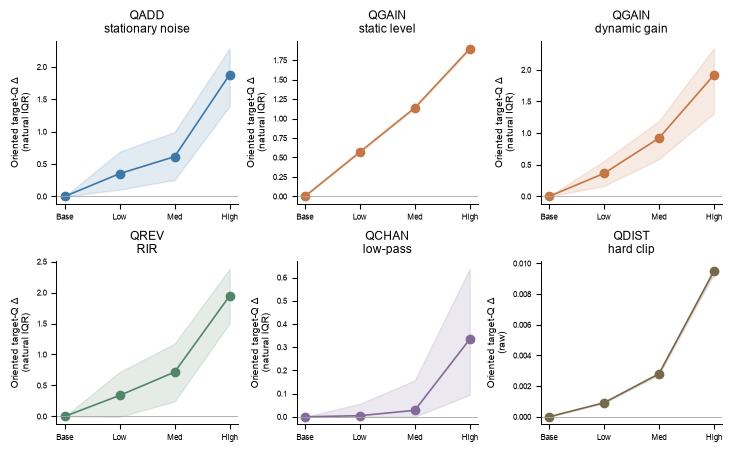

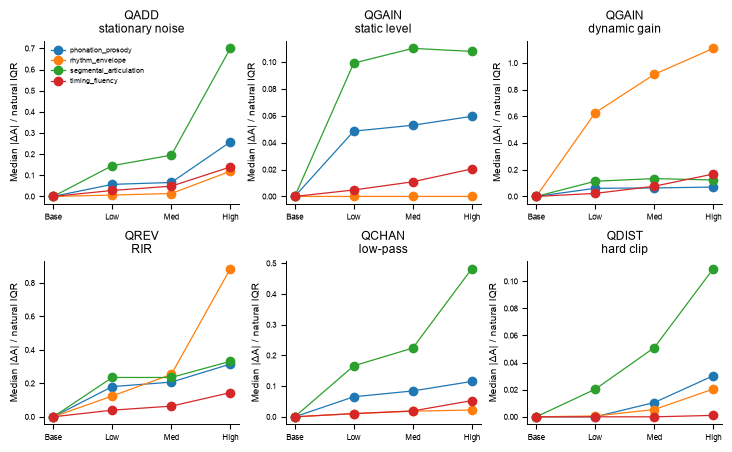

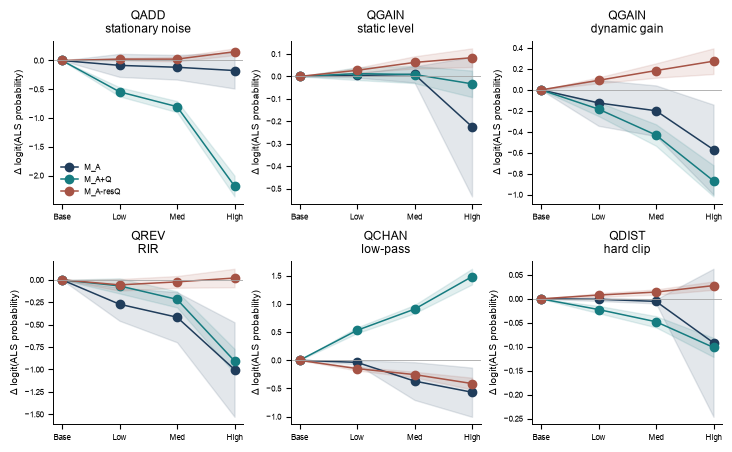

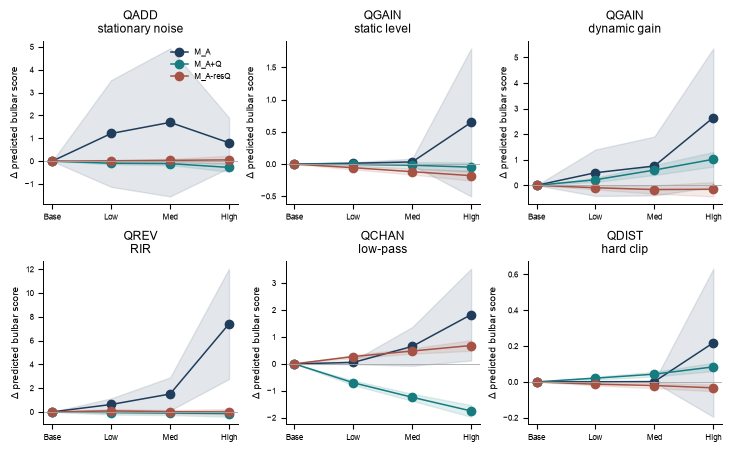

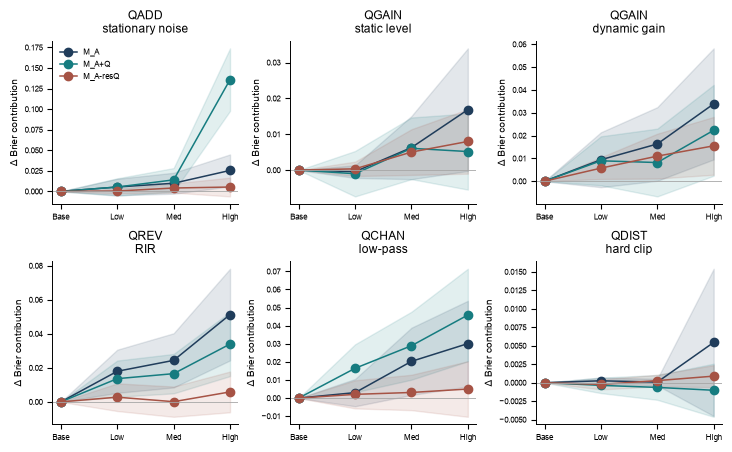

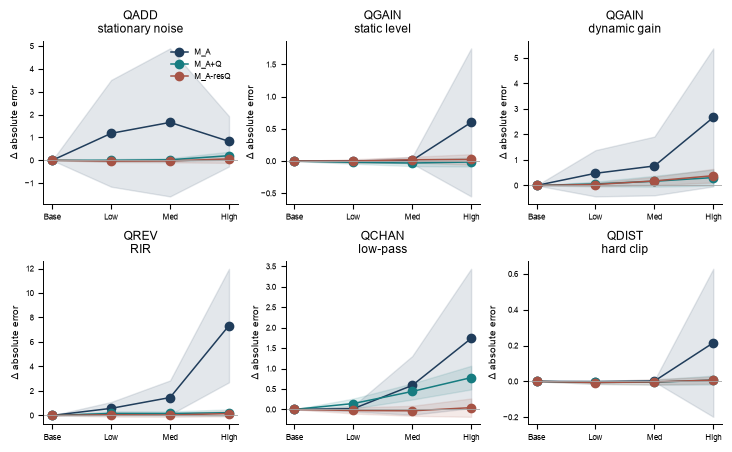

FIGURE-6 SOURCE PANELS: WRITTEN
Figure folder: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageE_controlled_perturbation_v1_0\final\figures


In [19]:
MM_TO_IN = 1 / 25.4

MODEL_PALETTE = {
    "M_A": "#203D5B",
    "M_A+Q": "#167C80",
    "M_A-resQ": "#A65345",
}
FAMILY_PALETTE = {
    "QADD": "#3D78A8",
    "QGAIN": "#C67645",
    "QREV": "#52866B",
    "QCHAN": "#846A98",
    "QDIST": "#766A4A",
}

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

TRANSFORM_ORDER = [
    "stationary_colored_broadband",
    "uniform_level_shift",
    "smooth_time_varying_gain",
    "RIR_convolution_RMS_matched",
    "upper_band_restriction",
    "symmetric_hard_clipping",
]
TRANSFORM_LABEL = {
    "stationary_colored_broadband": "QADD\nstationary noise",
    "uniform_level_shift": "QGAIN\nstatic level",
    "smooth_time_varying_gain": "QGAIN\ndynamic gain",
    "RIR_convolution_RMS_matched": "QREV\nRIR",
    "upper_band_restriction": "QCHAN\nlow-pass",
    "symmetric_hard_clipping": "QDIST\nhard clip",
}

def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def save_figure(fig, stem):
    for suffix in [".pdf", ".svg", ".png"]:
        kwargs = {"bbox_inches": "tight"}
        if suffix == ".png":
            kwargs["dpi"] = 400
        fig.savefig(FIGURES / f"{stem}{suffix}", **kwargs)

# 6A: diagnosis branch used for the larger target-Q verification display.
fig, axes = plt.subplots(
    2, 3,
    figsize=(183 * MM_TO_IN, 112 * MM_TO_IN),
    constrained_layout=True,
)
for ax, transform in zip(axes.ravel(), TRANSFORM_ORDER):
    g = target_verification.loc[
        target_verification["task"].eq("diagnosis")
        & target_verification["transform"].eq(transform)
    ].sort_values("dose_code")
    x = np.r_[0, g["dose_code"].to_numpy(float)]
    y = np.r_[0, g["median_oriented_delta"].to_numpy(float)]
    lo = np.r_[0, g["q25_oriented_delta"].to_numpy(float)]
    hi = np.r_[0, g["q75_oriented_delta"].to_numpy(float)]
    family = TARGET_CONFIG[transform]["family"]
    ax.plot(x, y, marker="o", linewidth=1.2, color=FAMILY_PALETTE[family])
    ax.fill_between(x, lo, hi, alpha=0.15, color=FAMILY_PALETTE[family])
    ax.axhline(0, linewidth=0.6, color="0.65")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["Base", "Low", "Med", "High"])
    ax.set_title(TRANSFORM_LABEL[transform])
    ax.set_ylabel(
        "Oriented target-Q Δ\n(natural IQR)"
        if g["scale"].iloc[0] == "natural IQR"
        else "Oriented target-Q Δ\n(raw)"
    )
    clean_axis(ax)
save_figure(fig, "Figure6A_Goal3_target_Q_verification_SOURCE")
plt.show()

# 6B: compact A movement, diagnosis source set.
plot_b = a_family_summary.loc[
    a_family_summary["task"].eq("diagnosis")
].copy()
a_families = sorted(plot_b["feature_family"].dropna().astype(str).unique())
fig, axes = plt.subplots(
    2, 3,
    figsize=(183 * MM_TO_IN, 112 * MM_TO_IN),
    constrained_layout=True,
)
for ax, transform in zip(axes.ravel(), TRANSFORM_ORDER):
    g = plot_b.loc[plot_b["transform"].eq(transform)]
    for af in a_families:
        h = g.loc[g["feature_family"].astype(str).eq(af)].sort_values("dose_code")
        if not len(h):
            continue
        ax.plot(
            np.r_[0, h["dose_code"].to_numpy(float)],
            np.r_[0, h["median_movement"].to_numpy(float)],
            marker="o",
            linewidth=0.9,
            label=af,
        )
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["Base", "Low", "Med", "High"])
    ax.set_title(TRANSFORM_LABEL[transform])
    ax.set_ylabel("Median |ΔA| / natural IQR")
    clean_axis(ax)
axes.ravel()[0].legend(frameon=False, fontsize=5)
save_figure(fig, "Figure6B_Goal3_acoustic_family_movement_SOURCE")
plt.show()

def clinical_source_plot(task, endpoint, ylabel, stem):
    local = prediction_primary.loc[prediction_primary["task"].eq(task)].copy()
    fig, axes = plt.subplots(
        2, 3,
        figsize=(183 * MM_TO_IN, 112 * MM_TO_IN),
        constrained_layout=True,
    )
    for ax, transform in zip(axes.ravel(), TRANSFORM_ORDER):
        g = local.loc[local["transform"].eq(transform)]
        for model_name in MODELS:
            h = g.loc[g["model"].eq(model_name)]
            summary = (
                h.groupby("dose_code", as_index=False)
                .agg(
                    mean=(endpoint, "mean"),
                    sem=(endpoint, "sem"),
                )
                .sort_values("dose_code")
                .reset_index(drop=True)
            )
            if not len(summary):
                continue
            x = np.r_[0, summary["dose_code"].to_numpy(float)]
            y = np.r_[0, summary["mean"].to_numpy(float)]
            se = np.r_[0, summary["sem"].fillna(0).to_numpy(float)]
            ax.plot(
                x, y,
                marker="o",
                linewidth=1.1,
                color=MODEL_PALETTE[model_name],
                label=model_name,
            )
            ax.fill_between(
                x,
                y - 1.96 * se,
                y + 1.96 * se,
                alpha=0.12,
                color=MODEL_PALETTE[model_name],
            )
        ax.axhline(0, linewidth=0.6, color="0.65")
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(["Base", "Low", "Med", "High"])
        ax.set_title(TRANSFORM_LABEL[transform])
        ax.set_ylabel(ylabel)
        clean_axis(ax)
    axes.ravel()[0].legend(frameon=False)
    save_figure(fig, stem)
    plt.show()

clinical_source_plot(
    "diagnosis",
    "delta_logit",
    "Δ logit(ALS probability)",
    "Figure6C_Goal3_diagnosis_model_movement_SOURCE",
)
clinical_source_plot(
    "severity",
    "delta_prediction",
    "Δ predicted bulbar score",
    "Figure6D_Goal3_severity_model_movement_SOURCE",
)
clinical_source_plot(
    "diagnosis",
    "delta_error",
    "Δ Brier contribution",
    "Figure6E1_Goal3_diagnosis_error_change_SOURCE",
)
clinical_source_plot(
    "severity",
    "delta_error",
    "Δ absolute error",
    "Figure6E2_Goal3_severity_error_change_SOURCE",
)

print("FIGURE-6 SOURCE PANELS: WRITTEN")
print("Figure folder:", FIGURES)


## 16. Stage-E computational seal

This seal means:

- every frozen source × baseline/perturbation/exemplar combination was attempted;
- the full response table was assembled from deterministic checkpoints;
- no perturbed waveform was used to fit or modify a clinical model;
- primary exemplar-averaged ΔQ, ΔA, prediction, error, GEE, bootstrap, and QDIST-sensitivity tables were written.

It does **not** automatically declare the scientific perturbation result positive. Target-Q ordering, support failures, clinical dose-response estimates, and figure legibility must be reviewed before Goal 3 is manuscript-frozen.

The remaining prespecified **supplementary robustness** work after this primary run is:

1. exemplar-level inference versus exemplar-averaged primary results;
2. fixed-frozen-segmentation sensitivity where technically feasible;
3. frozen HGB model-output perturbation sensitivity;
4. final Figure 6 composition and Figure S7/S8 package.

In [21]:
required_outputs = [
    TABLES / "goal3_execution_grid.csv",
    TABLES / "goal3_controlled_response_exemplar.csv",
    TABLES / "goal3_feature_delta_exemplar.csv",
    TABLES / "goal3_feature_delta.csv",
    TABLES / "goal3_prediction_delta_exemplar.csv",
    TABLES / "goal3_prediction_delta.csv",
    TABLES / "goal3_target_q_verification.csv",
    TABLES / "goal3_offtarget_q_summary.csv",
    TABLES / "goal3_A_family_movement_summary.csv",
    TABLES / "goal3_dose_response_tests.csv",
    TABLES / "goal3_bootstrap_ci.csv",
    TABLES / "goal3_qdist_baseline_negative_sensitivity.csv",
    TABLES / "goal3_support_failure_summary.csv",
    AUDIT / "goal3_stageE_runtime_environment.json",
    AUDIT / "goal3_stageE_media_hash_audit.csv",
    AUDIT / "goal3_stageE_bundle_qchan_audit.csv",
    AUDIT / "goal3_target_q_order_audit.csv",
]

missing = [
    str(path) for path in required_outputs
    if not path.exists() or path.stat().st_size == 0
]
if missing:
    raise RuntimeError(
        "Stage E cannot seal; missing/empty required outputs:\n"
        + "\n".join(missing)
    )

artifact_hashes = {
    str(path.relative_to(ROOT)): sha256_file(path)
    for path in required_outputs
}

measurement_unavailable_n = int(
    response["execution_status"].ne("PASS").sum()
)

prediction_unavailable = {
    model_name: int(
        response[f"prediction_status__{model_name}"].ne("PASS").sum()
    )
    for model_name in MODELS
}

target_all_ordered = bool(
    target_order_audit["strict_low_medium_high_order"].all()
)
target_all_expected = bool(
    target_order_audit["all_medians_expected_direction"].all()
)

seal = {
    "created_utc": utc_now(),
    "status": "PASS",
    "engine_version": ENGINE_VERSION,
    "run_signature": RUN_SIGNATURE,
    "diagnosis_sources": int(dx_sources["participant_id"].nunique()),
    "severity_sources": int(sev_sources["participant_id"].nunique()),
    "expected_full_response_rows": int(expected_full_rows),
    "observed_full_response_rows": int(len(response)),
    "measurement_unavailable_rows_retained": measurement_unavailable_n,
    "prediction_unavailable_rows_retained": prediction_unavailable,
    "n_bootstraps": N_BOOTSTRAPS,
    "model_refit_on_perturbed_audio": False,
    "primary_segmentation_rule": "fresh rerun for baseline and every perturbed waveform",
    "stochastic_exemplar_primary_rule": (
        "average participant outputs within transform x dose before inference"
    ),
    "target_q_full_sample_all_strictly_ordered": target_all_ordered,
    "target_q_full_sample_all_expected_direction": target_all_expected,
    "scientific_interpretation": (
        "Computational completion only. Direct-sensitivity claims require review "
        "of target verification, clinical dose-response estimates, support failures, "
        "and prespecified robustness analyses."
    ),
    "remaining_supplementary_robustness": [
        "exemplar-level versus exemplar-averaged inference",
        "fixed-frozen-segmentation sensitivity where feasible",
        "frozen HGB model-output perturbation sensitivity",
        "final Figure 6 / Figure S7 / Figure S8 publication freeze",
    ],
    "artifact_hashes": artifact_hashes,
}

atomic_json(seal, OUT / "GOAL3_STAGE_E_PRIMARY_SEAL.json")
atomic_json(seal, OUT / "DONE_PRIMARY.json")

print("=" * 78)
print("GOAL 3 STAGE E PRIMARY CONTROLLED EXPERIMENT: PASS")
print("=" * 78)
print("Output directory:", OUT)
print("Observed/expected full response rows:", len(response), "/", expected_full_rows)
print("Measurement-unavailable rows retained:", measurement_unavailable_n)
print("Prediction-unavailable rows retained:", prediction_unavailable)
print("2,000-participant bootstrap package: WRITTEN")
print("Target-Q strictly ordered in all task/transform branches:", target_all_ordered)
print("Target-Q medians all in expected direction:", target_all_expected)
print()
print("NEXT:")
print(
    "Send the final seal output plus goal3_target_q_order_audit, the clinical "
    "dose-response rows, bootstrap table, support-failure summary, and Figure-6 "
    "source panels for scientific audit before the final Goal-3 publication freeze."
)


GOAL 3 STAGE E PRIMARY CONTROLLED EXPERIMENT: PASS
Output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageE_controlled_perturbation_v1_0\final
Observed/expected full response rows: 14792 / 14792
Measurement-unavailable rows retained: 0
Prediction-unavailable rows retained: {'M_A': 0, 'M_A+Q': 191, 'M_A-resQ': 191}
2,000-participant bootstrap package: WRITTEN
Target-Q strictly ordered in all task/transform branches: True
Target-Q medians all in expected direction: True

NEXT:
Send the final seal output plus goal3_target_q_order_audit, the clinical dose-response rows, bootstrap table, support-failure summary, and Figure-6 source panels for scientific audit before the final Goal-3 publication freeze.
